<a href="https://colab.research.google.com/github/ilmcconnell/HRSM/blob/ilm-wisconet/HRSM_MAPPING_ML_pipeline_multiplePoints.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Initial settings (authorize, connect GD, install packages, etc)

In [1]:
# @title get GEE authorization
import ee

# Trigger the authentication flow.
ee.Authenticate()
# Initialize the library.
ee.Initialize(project='run-hrsm')  # enter YOUR Google Earth Engine project name here.

In [2]:
# @title Connect to my Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# !cp -r '/content/gdrive/My Drive/NIFA_Download/StartFolder/CDL_sites/' .

In [4]:
# @title Install necessary packages
!pip install folium
!pip install geopandas
!pip install netCDF4
!pip install --upgrade xee
!pip install rasterio
!pip install ipywidgets
!pip install permetrics==2.0.0
!pip install mapie
!pip install scikit-learn==1.5.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.4/265.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 92.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour 

In [5]:
# @title Import packages
from mapie.regression import SplitConformalRegressor, ConformalizedQuantileRegressor
import lightgbm as lgb

import folium
from folium import Figure
import geopandas as gpd
import json
import geemap
import numpy as np
from shapely.geometry import mapping
import pandas as pd
import netCDF4 as nc
import xarray
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.crs import CRS
import math
import time
import os
from datetime import datetime, timedelta
import joblib
import ipywidgets as widgets
from IPython.display import display
from permetrics import RegressionMetric
import osgeo.gdal as gdal
# import richdem as rd
# import pyflwdir
from osgeo import osr, gdalconst
from scipy.stats import rankdata

## Define study site: randomly choose points

This is a demo for ML runing pipeline, showing you how to run the trained ML models online for multiple points.

In this case study, we are going to generate stratified samples based on the irrigation calssification data and climate region data.

Irrigation maps:

Xie, Y., & Lark, T. J. (2021). Mapping annual irrigation from Landsat imagery and environmental variables across the conterminous United States. Remote Sensing of Environment, 260, 112445. https://doi.org/10.1016/j.rse.2021.112445

climate classification maps:

Beck, H. E., Zimmermann, N. E., McVicar, T. R., Vergopolan, N., Berg, A., & Wood, E. F. (2018). Present and future Köppen-Geiger climate classification maps at 1-km resolution. Scientific data, 5(1), 1-12. https://doi.org/10.1038/sdata.2018.214



In [6]:
# #@title Request irrigation data

# LANID2018_20 = ee.Image("users/xyhuwmir/LANID/update/LANID2018-2020")
# LANID2016 = ee.Image("projects/ee-scai62/assets/lanid2016")
# LANID2017 = ee.Image("projects/ee-scai62/assets/lanid2017")
# LANID2018 = LANID2018_20.select('irMap18')
# LANID2019 = LANID2018_20.select('irMap19')
# LANID2020 = LANID2018_20.select('irMap20')
# LANID_irrigation = (
#     LANID2018.eq(1)
#     .And(LANID2019.eq(1))
#     .And(LANID2020.eq(1))
#     .And(LANID2016.eq(1))
#     .And(LANID2017.eq(1))
# )

# LANID_binary = ee.Image.constant(2).where(LANID_irrigation.eq(1), 1)

In [7]:
# #@title Request climate data
# koppen_geiger_COUNS_1991_2020 = ee.Image("projects/ee-scai62/assets/koppen_geiger_COUNS_1991_2020")

# """
# 14: Cfa  Temperate, no dry season, hot summer  [200 255 80]
# 25: Dfa  Cold, no dry season, hot summer       [0 255 255]

# 4:  BWh  Arid, desert, hot                     [255 0 0]
# 5:  BWk  Arid, desert, cold                    [255 150 150]
# 6:  BSh  Arid, steppe, hot                     [245 165 0]
# 7:  BSk  Arid, steppe, cold                    [255 220 100]


# """

# koppen_reclassified = (
#     koppen_geiger_COUNS_1991_2020
#     .where(koppen_geiger_COUNS_1991_2020.eq(14), 1)
#     .where(
#         koppen_geiger_COUNS_1991_2020.eq(4)
#         .Or(koppen_geiger_COUNS_1991_2020.eq(5))
#         .Or(koppen_geiger_COUNS_1991_2020.eq(6))
#         .Or(koppen_geiger_COUNS_1991_2020.eq(7)),
#         2
#     )
#     .where(
#         koppen_geiger_COUNS_1991_2020.neq(14)
#         .And(koppen_geiger_COUNS_1991_2020.neq(4))
#         .And(koppen_geiger_COUNS_1991_2020.neq(5))
#         .And(koppen_geiger_COUNS_1991_2020.neq(6))
#         .And(koppen_geiger_COUNS_1991_2020.neq(7)),
#         0
#     )
# )
# # print(koppen_reclassified.getInfo())

In [8]:
# # @title Combine two classification layers
# final_image = LANID_binary.multiply(100).add(koppen_reclassified)
# band_names = final_image.bandNames()
# print(band_names.getInfo())

# valid_classes = ee.List([101, 102, 201, 202])

# masked_image = final_image.updateMask(
#     final_image.select('constant').remap(valid_classes, ee.List.repeat(1, valid_classes.size()))
# )

In [9]:
# @title The next cell is too slow, you can use this alternative: export csv file to google drive first, then load it here

# region = ee.FeatureCollection('projects/ee-scai62/assets/openET_states')
# scale = masked_image.projection().nominalScale()

# random_points = masked_image.stratifiedSample(
#     numPoints=200,
#     classBand='constant',
#     region=region.geometry(),
#     scale=scale,
#     geometries=True,
#     classValues=[101, 102, 201, 202],
#     classPoints=[50, 50, 50, 50],
#     seed=42
# )

# def add_coords(feature):
#     coords = feature.geometry().coordinates()
#     return feature.set({
#         'longitude': coords.get(0),
#         'latitude': coords.get(1)
#     })

# random_points = random_points.map(add_coords)


# # Export random_points to Google Drive as CSV
# export_task = ee.batch.Export.table.toDrive(
#     collection=random_points,
#     description='random_points_irrigation_climate',
#     # folder='GEE_exports',   # optional: folder name in your Drive
#     fileNamePrefix='random_points_irrigation_climate',
#     fileFormat='CSV'
# )

# # Start the export task
# export_task.start()

In [10]:
# # @title Generate random points within  classes
# import os

# if os.path.exists('random_points_irrigation_climate.csv'):
#   df_random_points = pd.read_csv('random_points_irrigation_climate.csv')
# else:
#   region = ee.FeatureCollection('projects/ee-scai62/assets/openET_states')

#   random_points = final_image.stratifiedSample(
#       numPoints=200,
#       classBand='constant',
#       region=region.geometry(),
#       scale=30,
#       geometries=True,
#       classValues=[101, 102, 201, 202],
#       classPoints=[50, 50, 50, 50],
#       seed=42
#   )

#   def add_coords(feature):
#       coords = feature.geometry().coordinates()
#       return feature.set({
#           'longitude': coords.get(0),
#           'latitude': coords.get(1)
#       })

#   random_points = random_points.map(add_coords)

#   fc_dict = random_points.getInfo()

#   df_random_points = pd.DataFrame([{
#       'latitude': f['properties']['latitude'],
#       'longitude': f['properties']['longitude'],
#       'cropland': f['properties']['cropland']
#   } for f in fc_dict['features']])

#   df_random_points['ID'] = df_random_points.index
#   df_random_points.to_csv('random_points_2016_2024.csv', index=False)

In [11]:
# Wisconet station lat,lons by wisconet station ID
coords = [
	{'latitude': 45.158901, 'longitude': -89.117798, 'ID': 47, 'constant': 1},
	{'latitude': 43.2966, 'longitude': -89.3843, 'ID': 7, 'constant': 1},
	{'latitude': 45.032001, 'longitude': -91.199997, 'ID': 45, 'constant': 1},
	{'latitude': 44.253799, 'longitude': -90.268997, 'ID': 36, 'constant': 1},
	{'latitude': 46.8395, 'longitude': -91.013603, 'ID': 74, 'constant': 1},
	{'latitude': 44.481499, 'longitude': -88.405899, 'ID': 31, 'constant': 1},
	{'latitude': 44.1852, 'longitude': -90.742798, 'ID': 19, 'constant': 1},
	{'latitude': 42.85215, 'longitude': -89.754089, 'ID': 82, 'constant': 1},
	{'latitude': 43.002998, 'longitude': -89.848503, 'ID': 65, 'constant': 1},
	{'latitude': 44.104, 'longitude': -88.051003, 'ID': 30, 'constant': 1},
	{'latitude': 42.570999, 'longitude': -88.044998, 'ID': 23, 'constant': 1},
	{'latitude': 43.838001, 'longitude': -89.030403, 'ID': 50, 'constant': 1},
	{'latitude': 45.285801, 'longitude': -92.321297, 'ID': 38, 'constant': 1},
	{'latitude': 42.898701, 'longitude': -88.737198, 'ID': 21, 'constant': 1},
	{'latitude': 45.522598, 'longitude': -88.923897, 'ID': 57, 'constant': 1},
	{'latitude': 45.16864, 'longitude': -87.997787, 'ID': 81, 'constant': 1},
	{'latitude': 44.026001, 'longitude': -90.255997, 'ID': 39, 'constant': 1},
	{'latitude': 42.649902, 'longitude': -90.289154, 'ID': 69, 'constant': 1},
	{'latitude': 44.327999, 'longitude': -87.966003, 'ID': 29, 'constant': 1},
	{'latitude': 44.627586, 'longitude': -91.939346, 'ID': 53, 'constant': 1},
	{'latitude': 45.0509, 'longitude': -87.259804, 'ID': 9, 'constant': 1},
	{'latitude': 44.609001, 'longitude': -91.0, 'ID': 42, 'constant': 1},
	{'latitude': 45.755638, 'longitude': -88.563454, 'ID': 80, 'constant': 1},
	{'latitude': 45.775398, 'longitude': -90.643097, 'ID': 72, 'constant': 1},
	{'latitude': 45.302132, 'longitude': -89.50415, 'ID': 79, 'constant': 1},
	{'latitude': 43.2981, 'longitude': -87.932098, 'ID': 32, 'constant': 1},
	{'latitude': 43.854332, 'longitude': -89.777641, 'ID': 70, 'constant': 1},
	{'latitude': 45.884548, 'longitude': -92.609062, 'ID': 78, 'constant': 1},
	{'latitude': 44.717999, 'longitude': -90.596603, 'ID': 20, 'constant': 1},
	{'latitude': 44.118801, 'longitude': -89.533302, 'ID': 1, 'constant': 1},
	{'latitude': 45.084621, 'longitude': -91.919167, 'ID': 76, 'constant': 1},
	{'latitude': 45.946201, 'longitude': -91.094704, 'ID': 73, 'constant': 1},
	{'latitude': 44.504025, 'longitude': -89.024918, 'ID': 55, 'constant': 1},
	{'latitude': 43.535099, 'longitude': -88.252701, 'ID': 33, 'constant': 1},
	{'latitude': 44.401798, 'longitude': -87.664597, 'ID': 15, 'constant': 1},
	{'latitude': 46.289001, 'longitude': -90.435997, 'ID': 41, 'constant': 1},
	{'latitude': 43.597, 'longitude': -90.625999, 'ID': 24, 'constant': 1},
	{'latitude': 42.830002, 'longitude': -90.7882, 'ID': 3, 'constant': 1},
	{'latitude': 43.451145, 'longitude': -88.977783, 'ID': 62, 'constant': 1},
	{'latitude': 44.556, 'longitude': -87.654297, 'ID': 8, 'constant': 1},
	{'latitude': 46.076, 'longitude': -89.838303, 'ID': 40, 'constant': 1},
	{'latitude': 46.632702, 'longitude': -91.681198, 'ID': 52, 'constant': 1},
	{'latitude': 44.7603, 'longitude': -90.097801, 'ID': 5, 'constant': 1},
	{'latitude': 44.030289, 'longitude': -90.934776, 'ID': 75, 'constant': 1},
	{'latitude': 42.887489, 'longitude': -90.231529, 'ID': 84, 'constant': 1},
	{'latitude': 44.401226, 'longitude': -91.559906, 'ID': 54, 'constant': 1},
	{'latitude': 43.853901, 'longitude': -89.283798, 'ID': 49, 'constant': 1},
	{'latitude': 44.789398, 'longitude': -87.4561, 'ID': 14, 'constant': 1},
	{'latitude': 42.976002, 'longitude': -88.120003, 'ID': 37, 'constant': 1},
	{'latitude': 44.59, 'longitude': -91.265999, 'ID': 43, 'constant': 1},
	{'latitude': 44.446098, 'longitude': -89.520699, 'ID': 34, 'constant': 1},
	{'latitude': 43.777199, 'longitude': -87.9515, 'ID': 60, 'constant': 1},
	{'latitude': 42.789001, 'longitude': -89.172997, 'ID': 26, 'constant': 1},
	{'latitude': 43.344799, 'longitude': -89.7117, 'ID': 18, 'constant': 1},
	{'latitude': 45.654598, 'longitude': -89.268204, 'ID': 2, 'constant': 1},
	{'latitude': 45.523331, 'longitude': -91.844292, 'ID': 77, 'constant': 1},
	{'latitude': 43.369999, 'longitude': -90.383003, 'ID': 27, 'constant': 1},
	{'latitude': 43.905602, 'longitude': -88.846703, 'ID': 28, 'constant': 1},
	{'latitude': 44.842499, 'longitude': -92.6129, 'ID': 71, 'constant': 1},
	{'latitude': 46.10701, 'longitude': -90.80793, 'ID': 68, 'constant': 1},
	{'latitude': 45.219101, 'longitude': -87.0662, 'ID': 11, 'constant': 1},
	{'latitude': 43.378399, 'longitude': -90.900002, 'ID': 48, 'constant': 1},
	{'latitude': 42.901299, 'longitude': -87.851196, 'ID': 51, 'constant': 1},
	{'latitude': 44.778999, 'longitude': -87.355598, 'ID': 10, 'constant': 1},
	{'latitude': 45.827, 'longitude': -91.861397, 'ID': 4, 'constant': 1},
	{'latitude': 44.880199, 'longitude': -87.329597, 'ID': 13, 'constant': 1},
	{'latitude': 44.999001, 'longitude': -88.342697, 'ID': 56, 'constant': 1},
	{'latitude': 43.84317, 'longitude': -88.370872, 'ID': 64, 'constant': 1},
	{'latitude': 44.004398, 'longitude': -87.8228, 'ID': 59, 'constant': 1},
	{'latitude': 43.025002, 'longitude': -89.536697, 'ID': 17, 'constant': 1},
	{'latitude': 42.527, 'longitude': -88.639999, 'ID': 25, 'constant': 1},
	{'latitude': 44.116699, 'longitude': -90.412102, 'ID': 35, 'constant': 1},
	{'latitude': 45.009998, 'longitude': -87.233498, 'ID': 12, 'constant': 1},
	{'latitude': 45.31929, 'longitude': -90.355469, 'ID': 67, 'constant': 1},
	{'latitude': 45.508121, 'longitude': -91.459503, 'ID': 83, 'constant': 1},
	{'latitude': 44.866001, 'longitude': -89.023552, 'ID': 58, 'constant': 1},
	{'latitude': 45.841, 'longitude': -89.667801, 'ID': 16, 'constant': 1},
	{'latitude': 44.943001, 'longitude': -92.287003, 'ID': 44, 'constant': 1},
	{'latitude': 42.7281, 'longitude': -88.028, 'ID': 46, 'constant': 1}
]
df_random_points = pd.DataFrame(coords)

In [12]:
df_random_points

,latitude,longitude,ID,constant
0,45.158901,-89.117798,47,1
1,43.296600,-89.384300,7,1
2,45.032001,-91.199997,45,1
3,44.253799,-90.268997,36,1
4,46.839500,-91.013603,74,1
...,...,...,...,...
74,45.508121,-91.459503,83,1
75,44.866001,-89.023552,58,1
76,45.841000,-89.667801,16,1
77,44.943001,-92.287003,44,1


In [13]:
# @title Define feature collections
lons_sub = ee.List(df_random_points['longitude'].tolist())
lats_sub = ee.List(df_random_points['latitude'].tolist())
idnum_sub = ee.List(df_random_points['ID'].tolist())
constant_sub = ee.List(df_random_points['constant'].tolist())

# Combine all lists together
combined = lons_sub.zip(lats_sub).zip(idnum_sub).zip(constant_sub)

# Create FeatureCollection with geometry and properties
points = combined.map(lambda x:
    ee.Feature(
        ee.Geometry.Point([
            ee.List(ee.List(ee.List(x).get(0)).get(0)).get(0),  # lon
            ee.List(ee.List(ee.List(x).get(0)).get(0)).get(1)   # lat
        ]),
        {
            'id_num': ee.List(ee.List(x).get(0)).get(1),       # id_num
            'constant': ee.List(x).get(1)                      # constant
        }
    )
)

feature_collection = ee.FeatureCollection(points)

In [14]:
import io
from PIL import Image

# @title Visualize CDL image and random points
# Map = geemap.Map(center=[40, -100], zoom=4)
m = geemap.Map(center=(float(df_random_points.latitude.mean()), float(df_random_points.longitude.mean())), zoom=6)

# Add random_points layer
m.addLayer(feature_collection, {'color': 'red'}, 'Random Points')
# Map.addLayer(region)

# Map.addLayerControl()
# m  # hide js element display so notebook shows on GitHub OK.


## Read ee.images (constant images)

In [15]:
#@title read images to array

# Landcover
LC = ee.ImageCollection('USGS/NLCD_RELEASES/2019_REL/NLCD').filterDate('2016-01-01', '2018-01-01').select('landcover').first()
lc_proj = LC.projection()

#polaris
bd_0_5 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/bd_mean').filterMetadata('system:index', 'equals', 'bd_0_5').first().rename('bd_0_5')
bd_5_15 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/bd_mean').filterMetadata('system:index', 'equals', 'bd_5_15').first().rename('bd_5_15')
bd_15_30 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/bd_mean').filterMetadata('system:index', 'equals', 'bd_15_30').first().rename('bd_15_30')
bd_30_60 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/bd_mean').filterMetadata('system:index', 'equals', 'bd_30_60').first().rename('bd_30_60')
bd_60_100 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/bd_mean').filterMetadata('system:index', 'equals', 'bd_60_100').first().rename('bd_60_100')
bd_0_100 = bd_0_5.multiply(0.05).add(bd_5_15.multiply(0.1)).add(bd_15_30.multiply(0.15)).add(bd_30_60.multiply(0.3)).add(bd_60_100.multiply(0.4)).rename('bd_0_100')

clay_0_5 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/clay_mean').filterMetadata('system:index', 'equals', 'clay_0_5').first().rename('clay_0_5')
clay_5_15 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/clay_mean').filterMetadata('system:index', 'equals', 'clay_5_15').first().rename('clay_5_15')
clay_15_30 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/clay_mean').filterMetadata('system:index', 'equals', 'clay_15_30').first().rename('clay_15_30')
clay_30_60 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/clay_mean').filterMetadata('system:index', 'equals', 'clay_30_60').first().rename('clay_30_60')
clay_60_100 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/clay_mean').filterMetadata('system:index', 'equals', 'clay_60_100').first().rename('clay_60_100')
clay_0_100 = clay_0_5.multiply(0.05).add(clay_5_15.multiply(0.1)).add(clay_15_30.multiply(0.15)).add(clay_30_60.multiply(0.3)).add(clay_60_100.multiply(0.4)).rename('clay_0_100')

ksat_0_5 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/ksat_mean').filterMetadata('system:index', 'equals', 'ksat_0_5').first().rename('ksat_0_5')
ksat_5_15 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/ksat_mean').filterMetadata('system:index', 'equals', 'ksat_5_15').first().rename('ksat_5_15')
ksat_15_30 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/ksat_mean').filterMetadata('system:index', 'equals', 'ksat_15_30').first().rename('ksat_15_30')
ksat_30_60 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/ksat_mean').filterMetadata('system:index', 'equals', 'ksat_30_60').first().rename('ksat_30_60')
ksat_60_100 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/ksat_mean').filterMetadata('system:index', 'equals', 'ksat_60_100').first().rename('ksat_60_100')


sand_0_5 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/sand_mean').filterMetadata('system:index', 'equals', 'sand_0_5').first().rename('sand_0_5')
sand_5_15 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/sand_mean').filterMetadata('system:index', 'equals', 'sand_5_15').first().rename('sand_5_15')
sand_15_30 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/sand_mean').filterMetadata('system:index', 'equals', 'sand_15_30').first().rename('sand_15_30')
sand_30_60 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/sand_mean').filterMetadata('system:index', 'equals', 'sand_30_60').first().rename('sand_30_60')
sand_60_100 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/sand_mean').filterMetadata('system:index', 'equals', 'sand_60_100').first().rename('sand_60_100')
sand_0_100 = sand_0_5.multiply(0.05).add(sand_5_15.multiply(0.1)).add(sand_15_30.multiply(0.15)).add(sand_30_60.multiply(0.3)).add(sand_60_100.multiply(0.4)).rename('sand_0_100')

silt_0_5 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/silt_mean').filterMetadata('system:index', 'equals', 'silt_0_5').first().rename('silt_0_5')
silt_5_15 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/silt_mean').filterMetadata('system:index', 'equals', 'silt_5_15').first().rename('silt_5_15')
silt_15_30 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/silt_mean').filterMetadata('system:index', 'equals', 'silt_15_30').first().rename('silt_15_30')
silt_30_60 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/silt_mean').filterMetadata('system:index', 'equals', 'silt_30_60').first().rename('silt_30_60')
silt_60_100 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/silt_mean').filterMetadata('system:index', 'equals', 'silt_60_100').first().rename('silt_60_100')
silt_0_100 = silt_0_5.multiply(0.05).add(silt_5_15.multiply(0.1)).add(silt_15_30.multiply(0.15)).add(silt_30_60.multiply(0.3)).add(silt_60_100.multiply(0.4)).rename('silt_0_100')

polaris = bd_0_5.addBands(bd_0_100)\
          .addBands(ksat_0_5).addBands(ksat_0_5)\
          .addBands(clay_0_5).addBands(clay_0_100)\
          .addBands(sand_0_5).addBands(sand_0_100)\
          .addBands(silt_0_5).addBands(silt_0_100)

polaris_ksat = ksat_0_5.addBands(ksat_5_15).addBands(ksat_15_30).addBands(ksat_30_60).addBands(ksat_60_100)


dem_image = ee.Image('projects/ee-scai62/assets/COUNS_dem100m')
TWII_image = ee.Image('projects/ee-scai62/assets/CONUS_dem100m_TWII')
aspect_image = ee.Image('projects/ee-scai62/assets/CONUS_dem100m_aspect')
slopeDegree_image = ee.Image('projects/ee-scai62/assets/CONUS_dem100m_slopeDegree')

dem_image = dem_image.reproject(lc_proj)
TWII_image = TWII_image.reproject(lc_proj)
aspect_image = aspect_image.reproject(lc_proj)
slopeDegree_image = slopeDegree_image.reproject(lc_proj)

dem_image = dem_image.reproject(crs='EPSG:4326', scale=100)
TWII_image = TWII_image.reproject(crs='EPSG:4326', scale=100)
aspect_image = aspect_image.reproject(crs='EPSG:4326', scale=100)
slopeDegree_image = slopeDegree_image.reproject(crs='EPSG:4326', scale=100)

In [16]:
# @title extract values from constant images

dem_values = dem_image.sampleRegions(collection=feature_collection,scale=100)
elevation_arr = np.array(dem_values.aggregate_array('b1').getInfo())[:]
dem_idnum_arr = np.array(dem_values.aggregate_array('id_num').getInfo())[:]
TWII_values = TWII_image.sampleRegions(collection=feature_collection,scale=100)
TWII_arr = np.array(TWII_values.aggregate_array('b1').getInfo())[:]
aspect_values = aspect_image.sampleRegions(collection=feature_collection,scale=100)
aspect_arr = np.array(aspect_values.aggregate_array('b1').getInfo())[:]
slopeDegree_values = slopeDegree_image.sampleRegions(collection=feature_collection,scale=100)
slopeDegree_arr = np.array(slopeDegree_values.aggregate_array('b1').getInfo())[:]


# extract pixel values of LC using feature collection
LC_values = LC.sampleRegions(collection=feature_collection,scale=100)
landcover_arr = np.array(LC_values.aggregate_array('landcover').getInfo())[:]
LC_idnum_arr = np.array(LC_values.aggregate_array('id_num').getInfo())[:]

# extract pixel values of Polaris soil using feature collection
polaris_values = polaris.sampleRegions(collection=feature_collection,scale=100)
ml_sand_0_5 = np.array(polaris_values.aggregate_array('sand_0_5').getInfo())[:]
ml_sand_0_100 = np.array(polaris_values.aggregate_array('sand_0_100').getInfo())[:]
ml_clay_0_5 = np.array(polaris_values.aggregate_array('clay_0_5').getInfo())[:]
ml_clay_0_100 = np.array(polaris_values.aggregate_array('clay_0_100').getInfo())[:]
ml_bd_0_5 = np.array(polaris_values.aggregate_array('bd_0_5').getInfo())[:]
ml_bd_0_100 = np.array(polaris_values.aggregate_array('bd_0_100').getInfo())[:]
ml_ksat_0_5 = np.array(polaris_values.aggregate_array('ksat_0_5').getInfo())[:]
polaris_idnum_arr = np.array(polaris_values.aggregate_array('id_num').getInfo())[:]


# extract pixel values of Polaris soil using feature collection
polaris_ksat_values = polaris_ksat.sampleRegions(collection=feature_collection,scale=100)
#ksat
ksat_0_5_arr = np.array(polaris_ksat_values.aggregate_array('ksat_0_5').getInfo())[:]
ksat_5_15_arr = np.array(polaris_ksat_values.aggregate_array('ksat_5_15').getInfo())[:]
ksat_15_30_arr = np.array(polaris_ksat_values.aggregate_array('ksat_15_30').getInfo())[:]
ksat_30_60_arr = np.array(polaris_ksat_values.aggregate_array('ksat_30_60').getInfo())[:]
ksat_60_100_arr = np.array(polaris_ksat_values.aggregate_array('ksat_60_100').getInfo())[:]


In [17]:
#@title processing constant values
elevation_arr[elevation_arr<-1000] = np.nan

sinAsp_arr = np.sin(aspect_arr/180*np.pi)
sinAsp_arr[aspect_arr==-1] = 0
cosAsp_arr = np.cos(aspect_arr/180*np.pi)
cosAsp_arr[aspect_arr == -1] = 0

ml_ksat_0_5 = np.power(10, ml_ksat_0_5)  # convert to cm/hr
ksat_0_5_arr = np.power(10, ksat_0_5_arr)
ksat_5_15_arr = np.power(10, ksat_5_15_arr)
ksat_15_30_arr = np.power(10, ksat_15_30_arr)
ksat_30_60_arr = np.power(10, ksat_30_60_arr)
ksat_60_100_arr = np.power(10, ksat_60_100_arr)

d0_5 = 0.05
d5_15 = 0.10
d15_30 = 0.15
d30_60 = 0.30
d60_100 = 0.40
d_total = d0_5 + d5_15 + d15_30 + d30_60 + d60_100
ml_ksat_0_100 = d_total/(d0_5/ksat_0_5_arr +
                                d5_15/ksat_5_15_arr +
                                d15_30/ksat_15_30_arr +
                                d30_60/ksat_30_60_arr +
                                d60_100/ksat_60_100_arr)


In [18]:
print("max ksat at surface: ", ml_ksat_0_5.max())
print("min ksat at surface: ", ml_ksat_0_5.min())
print("max ksat at rootzone: ", ml_ksat_0_100.max())
print("min ksat at rootzone: ", ml_ksat_0_100.min())
print("max slope", slopeDegree_arr.max())
print("min slope", slopeDegree_arr.min())

max ksat at surface:  24.555552633321277
min ksat at surface:  0.9200064638472555
max ksat at rootzone:  25.33668213661158
min ksat at rootzone:  0.182132296092242
max slope 5.706702709197998
min slope 0.09557373076677322


In [19]:
#@title reorganize dataframe

df_constant = pd.DataFrame({
    'ID': dem_idnum_arr,
    'elevation': elevation_arr,
    'sinAspect': sinAsp_arr,
    'cosAspect': cosAsp_arr,
    'slope': slopeDegree_arr,
    'landcover': landcover_arr,
    'sand_0_5[0-100]': ml_sand_0_5,
    'sand_0_100[0-100]': ml_sand_0_100,
    'clay_0_5[0-100]': ml_clay_0_5,
    'clay_0_100[0-100]': ml_clay_0_100,
    'ksat_0_5[cm/hr]': ml_ksat_0_5,
    'ksat_0_100[cm/hr]': ml_ksat_0_100,
    'bd_0_5[g/cm3]': ml_bd_0_5,
    'bd_0_100[g/cm3]': ml_bd_0_100})

merged_df = df_constant.merge(df_random_points, on='ID')


refer_id_arr = merged_df['ID'].to_numpy()
refer_lon_arr = merged_df['longitude'].to_numpy()
refer_lat_arr = merged_df['latitude'].to_numpy()

refer_id_idx_dict = {}
for i in range(len(refer_id_arr)):
    refer_id_idx_dict[refer_id_arr[i]] = i


len(refer_id_arr)


79

In [20]:
merged_df

,ID,elevation,sinAspect,cosAspect,slope,landcover,sand_0_5[0-100],sand_0_100[0-100],clay_0_5[0-100],clay_0_100[0-100],ksat_0_5[cm/hr],ksat_0_100[cm/hr],bd_0_5[g/cm3],bd_0_100[g/cm3],latitude,longitude,constant
0,47,462.243469,-0.108537,-0.994092,0.334581,82,27.880409,38.225499,8.957352,11.021242,1.905943,1.588020,1.435038,1.527205,45.158901,-89.117798,1
1,7,305.863586,0.634554,0.772879,0.581425,82,10.323525,10.037856,20.210079,24.354092,2.533685,2.432207,1.280629,1.348935,43.296600,-89.384300,1
2,45,305.938507,-0.950172,0.311725,1.009012,81,18.488504,33.213558,11.436643,13.784551,2.523956,1.299821,1.397751,1.576556,45.032001,-91.199997,1
3,36,295.531891,0.262039,0.965057,0.231921,82,50.344337,60.117084,24.417032,16.623494,22.410416,9.444142,0.996209,1.226416,44.253799,-90.268997,1
4,74,316.996948,-0.102523,-0.994731,3.633019,81,30.217831,21.283387,15.879774,40.625560,2.354330,0.185541,1.384654,1.437839,46.839500,-91.013603,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,83,459.490906,0.112354,-0.993668,3.528002,22,24.883106,41.759721,10.178644,10.457774,3.176977,1.063253,1.335014,1.608369,45.508121,-91.459503,1
75,58,344.608643,-0.437673,0.899134,0.885890,82,74.548615,84.502280,3.921112,3.160625,17.843483,21.781964,1.172451,1.443771,44.866001,-89.023552,1
76,16,487.196045,-0.996543,0.083073,0.829026,42,79.219482,87.170281,2.844500,2.191342,11.623861,18.718399,1.231831,1.495018,45.841000,-89.667801,1
77,44,345.327728,-0.757471,-0.652868,2.018511,21,27.020752,38.579122,13.006799,14.598082,2.615264,1.631585,1.319633,1.523108,44.943001,-92.287003,1


## Define study area and period

In [21]:
# prompt: get the boundary of feature_collection
roi = feature_collection.geometry().bounds()

# start_date = '2016-01-01'  # original
# end_date = '2025-01-01'  # original
start_date = '2021-07-16' # mine
end_date = '2026-02-10'  # mine
# start_date = '2026-02-09' # test
# end_date = '2026-02-10'  # test



start_datetime = datetime.strptime(start_date, '%Y-%m-%d')
end_datetime = datetime.strptime(end_date, '%Y-%m-%d')  # end_date

num_hours = int((end_datetime - start_datetime).total_seconds()/3600)
print(num_hours)

40080


## Get ee imagecollections

In [22]:
# @title Era5-land
start_date_era5 = (datetime.strptime(start_date, '%Y-%m-%d')- timedelta(hours=120+24)).strftime('%Y-%m-%d')

era5hour_short = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")\
                    .filterBounds(roi).filterDate(start_date_era5, end_date)\
                    .map(lambda img: img.addBands(
                        img.select('u_component_of_wind_10m').hypot(img.select('v_component_of_wind_10m')).rename('wind_10m')
                        )).select([
                            'temperature_2m',    # 2m air temperature, K
                            'dewpoint_temperature_2m',  # 2m dew point temperature, K
                            'wind_10m',  # wind speed, m/s
                            'surface_pressure',  # atmospheric surface pressure, Pa
                            ])


era5hour_mid = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY").filterBounds(roi).filterDate(start_date_era5, end_date).select([
    'surface_solar_radiation_downwards_hourly',  # solar radiation, J
    'surface_thermal_radiation_downwards_hourly',  # thermal radiation, J
    ])


era5hour_long = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY").filterBounds(roi).filterDate(start_date_era5, end_date).select([
    'total_evaporation_hourly',  # total evaporation, m
    'total_precipitation_hourly',   # precipitation, m
    ])


In [23]:
# @title HLSL30

###note: no scale factor for HLSL30 product.

def bitwiseExtract(img, fromBit, toBit):
  maskSize = ee.Number(1).add(toBit).subtract(fromBit)
  mask = ee.Number(1).leftShift(maskSize).subtract(1)
  return img.rightShift(fromBit).bitwiseAnd(mask)

# remove low quality data
def maskHLSL30(image):
  qcDay = image.select('Fmask')
  cloud = bitwiseExtract(qcDay, 1, 1).eq(0)
  cloudshadow = bitwiseExtract(qcDay, 3, 3).eq(0)
  snowice = bitwiseExtract(qcDay, 4, 4).eq(0)
  water = bitwiseExtract(qcDay, 5, 5).eq(0)
  aerosol = bitwiseExtract(qcDay, 6, 7).lte(2)
  mask = cloud.And(cloudshadow).And(snowice).And(water).And(aerosol)

  return    image.updateMask(mask).copyProperties(image, ['system:time_start'])


HLSL30 = ee.ImageCollection("NASA/HLS/HLSL30/v002").filterBounds(roi)\
    .filterDate(start_date, end_date).map(maskHLSL30) \
		.select(['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B9', 'B10', 'B11'])



# HLSL30_timestamps = HLSL30.aggregate_array('system:time_start')
# HLSL30_datetime_list = HLSL30_timestamps.map(
#     lambda t: ee.Date(t).format('YYYY-MM-dd HH')
# )
# HLSL30_datetime_list_py = HLSL30_datetime_list.getInfo()
# print(HLSL30_datetime_list_py[:10])  # preview first 10
# print("Total unique timestamps:", len(set(HLSL30_datetime_list_py)))

In [24]:
# @title Sentinel-2
# Sentinel-2 images

# old version
# def maskSentinel2(img):
#   cloudOpaqueBitMask = (1 << 10);
#   cloudCirrusMask = (1 << 11);
#   # Get the pixel QA band.
#   qa = img.select('QA60')
#   # Both flags should be set to zero, indicating clear conditions.
#   mask = qa.bitwiseAnd(cloudOpaqueBitMask).eq(0) \
#                 .And(qa.bitwiseAnd(cloudCirrusMask).eq(0))
#   return img.updateMask(mask).copyProperties(img, ['system:time_start'])                  #.multiply(0.0001).toFloat().copyProperties(img, ['mydate'])  # after applying updateMask(). all properties will be lost


def maskSentinel2(img):
  # Get the pixel QA band.
  scl = img.select('SCL')
  mask = scl.neq(8).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11))
  return img.updateMask(mask).copyProperties(img, ['system:time_start'])

# def add_date(img):
#   date_start = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd-HH')
#   return img.set('mydate', date_start)


Sentinel2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")\
            .filterDate(start_date, end_date).filterBounds(roi)\
            .map(maskSentinel2)\
            .select(['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12'])


# Sentinel2 = Sentinel2.map(add_date)

# Sentinel2_timestamps = Sentinel2.aggregate_array('system:time_start')
# Sentinel2_datetime_list = Sentinel2_timestamps.map(
#     lambda t: ee.Date(t).format('YYYY-MM-dd HH')
# )
# Sentinel2_datetime_list_py = Sentinel2_datetime_list.getInfo()
# print(Sentinel2_datetime_list_py[:10])  # preview first 10
# print("Total unique timestamps:", len(set(Sentinel2_datetime_list_py)))

In [25]:
# @title Sentinel-1

def preprocess_vv(image):
    vv_masked = image.updateMask(image.gt(-20).And(image.lt(-5)))
    vv_filtered = vv_masked.convolve(ee.Kernel.gaussian(3))
    return vv_filtered #.rename('VV').copyProperties(image, ['system:time_start'])

# Define preprocessing for VH
def preprocess_vh(image):
    vh_masked = image.updateMask(image.gt(-30).And(image.lt(-10)))
    vh_filtered = vh_masked.convolve(ee.Kernel.gaussian(3))
    return vh_filtered #.rename('VH').copyProperties(image, ['system:time_start'])


def merge_bands(image):
    vv = image.select('VV')
    vh = image.select('VH')
    angle = image.select('angle')

    vv_prep = preprocess_vv(vv)      # Apply mask + smoothing to VV
    vh_prep = preprocess_vh(vh)      # Apply mask + smoothing to VH

    merged = vv_prep.addBands(vh_prep).addBands(angle.rename('angle'))

    return merged.copyProperties(image, ['system:time_start'])

def to_float(image):
    all_bands = image.bandNames()
    return image.select(all_bands).float().copyProperties(image, ['system:time_start'])

Sentinel1 = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterDate(start_date, end_date)
    .filterBounds(roi)
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
    # .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
    .sort('SLC_Processing_start')
    .map(merge_bands).map(to_float)
)


# Sentinel1_timestamps = Sentinel1.aggregate_array('system:time_start')
# Sentinel1_datetime_list = Sentinel1_timestamps.map(
#     lambda t: ee.Date(t).format('YYYY-MM-dd HH')
# )
# Sentinel1_datetime_list_py = Sentinel1_datetime_list.getInfo()
# print(Sentinel1_datetime_list_py[:10])  # preview first 10
# print("Total unique timestamps:", len(set(Sentinel1_datetime_list_py)))

## Prepare Xy

## Extract data from image collection

The following code is to extract pixel values from imagecollections. Due to the request limiation of google earth engine (e.g., each time no more than 5000 observations), the feature collection is divdided into samll groups, and the study period is divided into small periods, and the parallel processing strategy is applied.

In [26]:
#@title Create year, doy, hour list: doy is an input for ML models, year, doy and hour provide time info for results
# start_datetime = datetime(2016, 1, 1, 0, 0, 0)
print(f"{start_datetime=}")
datetime_list = [start_datetime + timedelta(hours=i) for i in range(num_hours)]
doy_list = np.array([dt.timetuple().tm_yday for dt in datetime_list])
year_list = np.array([dt.year for dt in datetime_list])
hour_list = np.array([dt.hour for dt in datetime_list])
print(len(doy_list))

start_datetime=datetime.datetime(2021, 7, 16, 0, 0)
40080


In [27]:
# @title Define weights for ERA5 data
def make_weights(n):
    weights = 1.0 / np.arange(n, 0, -1)      # reversed sequence [n ... 1]
    weights = weights / weights.sum()        # normalize
    return weights, ee.List(weights.tolist())

# Short-term (24h)
short_term_weights, ee_short_term_weights = make_weights(24)
# print("Short-term weights:", short_term_weights)

# Mid-term (72h)
mid_term_weights, ee_mid_term_weights = make_weights(72)
# print("Mid-term weights:", mid_term_weights)

# Long-term (120h)
long_term_weights, ee_long_term_weights = make_weights(120)
# print("Long-term weights:", long_term_weights)

In [28]:
start_datetime = datetime.strptime(start_date, '%Y-%m-%d')
end_datetime = datetime.strptime(end_date, '%Y-%m-%d')  # end_date

num_hours = int((end_datetime - start_datetime).total_seconds()/3600)
print(num_hours)

era5hour_arr = np.zeros((8, num_hours, len(refer_id_arr)))
sentinel1_arr = np.zeros((3, num_hours, len(refer_id_arr)))
HLSL30_arr = np.zeros((9, num_hours, len(refer_id_arr)))
Sentinel2_arr = np.zeros((10, num_hours, len(refer_id_arr)))

era5hour_arr[:] = np.nan
sentinel1_arr[:] = np.nan
HLSL30_arr[:] = np.nan
Sentinel2_arr[:] = np.nan

40080


In [29]:
start_datetime = datetime.strptime(start_date, '%Y-%m-%d')
end_datetime = datetime.strptime(end_date, '%Y-%m-%d')  # end_date
current_datetime = start_datetime
tfirsts = []
tlasts = []
deltaa = 15 # hours
while current_datetime < end_datetime:
  tfirsts.append(current_datetime)
  tlasts.append( current_datetime + timedelta(hours=deltaa))
  current_datetime += timedelta(hours=deltaa)

print(len(tfirsts))

2672


In [30]:
len(tfirsts)

2672

In [31]:
# @title define drive path to write GEE parallel processing data

from pathlib import Path

gdrive_data_dir = Path('/content/gdrive/MyDrive/HRSM/')
gdrive_data_dir.mkdir(parents=True, exist_ok=True)
gdrive_data_dir.exists()


True

In [32]:
#@title Load any pre-saved ERA5 data, check for nans, get missing tfirsts
from tqdm.auto import tqdm

era5hour_data_npy_file_name = 'era5hour_arr_irriClimate.npy'
era5_npy_path = gdrive_data_dir / era5hour_data_npy_file_name
if era5_npy_path.exists():
    print(f'loading {era5_npy_path.name}')
    era5hour_arr = np.load(era5_npy_path)

    # 1. Find indices of NaNs
    nan_indices = np.where(np.isnan(era5hour_arr))

    if nan_indices[0].size > 0:
        print(f"Found {nan_indices[0].size:,} NaN elements.")

        # 2. Extract unique time indices (axis 1)
        unique_nan_time_indices = np.unique(nan_indices[1])

        # 3. Calculate which 15-hour window (tfirst) each index belongs to
        # window_idx = floor(hours_since_start / deltaa)
        nan_window_indices = sorted(list(set(unique_nan_time_indices // deltaa)))

        # 4. Map back to actual tfirst datetimes
        # tfirsts = [tfirsts[i] for i in nan_window_indices if i < len(tfirsts)]
        tfirst_idxs = [i for i in nan_window_indices if i < len(tfirsts)]
        print(f"Need to re-run {len(tfirst_idxs)} time windows.")
        example_tfirsts_to_rerun = [tfirsts[tfirst_idx] for tfirst_idx in tfirst_idxs[:10]]
        print(f"Example tfirsts to re-run: {example_tfirsts_to_rerun}")
    else:
        print("No NaNs detected.")

else:
    print("File not found. Initializing fresh.")




loading era5hour_arr_irriClimate.npy
No NaNs detected.


In [33]:
# @title parallel processing  for ERA5-Land
import concurrent.futures
import traceback

def process_day(idx, feature_collection_crop):
  print(f'is running the {idx}th group')
  tfirst = tfirsts[idx]
  tlast = tlasts[idx]

  # ERA5 short
  era5hour_short_sub = era5hour_short.filterDate(tfirst, tlast)

  era5hour_sampled_points = era5hour_short_sub.map(lambda image: image.sampleRegions(
    collection=feature_collection_crop,
    scale=100  # Adjust scale as needed
  )).flatten()
  time.sleep(2) # Adjust the delay as needed
  points_list = era5hour_sampled_points.getInfo()['features']
  system_times = [point['id'] for point in points_list]
  data = [point['properties'] for point in points_list]
  df = pd.DataFrame(data)
  # print(len(df))
  df['id_idx'] = [refer_id_idx_dict[id] for id in df['id_num'].tolist()]
  df['time_idx'] = [int((datetime.strptime(systm[0:8] + systm[9:11], '%Y%m%d%H') - start_datetime).total_seconds()/3600) for systm in system_times]
  grouped_df = df.groupby(['time_idx', 'id_idx']).mean()
  indices = grouped_df.index.tolist()
  for idx in indices:
    era5hour_arr[0, idx[0], idx[1]] = grouped_df.loc[idx, 'temperature_2m']   # 2m air temperature, K
    era5hour_arr[1, idx[0], idx[1]] = grouped_df.loc[idx, 'dewpoint_temperature_2m']   # 2m dew point temperature, K
    era5hour_arr[2, idx[0], idx[1]] = grouped_df.loc[idx, 'wind_10m']   # wind speed, m/s
    era5hour_arr[3, idx[0], idx[1]] = grouped_df.loc[idx, 'surface_pressure']  # atmospheric surface pressure, Pa


  # ERA5 middle
  era5hour_mid_sub = era5hour_mid.filterDate(tfirst, tlast)
  era5hour_sampled_points = era5hour_mid_sub.map(lambda image: image.sampleRegions(
    collection=feature_collection_crop,
    scale=100  # Adjust scale as needed
  )).flatten()
  time.sleep(2) # Adjust the delay as needed
  points_list = era5hour_sampled_points.getInfo()['features']
  system_times = [point['id'] for point in points_list]
  data = [point['properties'] for point in points_list]
  df = pd.DataFrame(data)
  df['id_idx'] = [refer_id_idx_dict[id] for id in df['id_num'].tolist()]
  df['time_idx'] = [int((datetime.strptime(systm[0:8] + systm[9:11], '%Y%m%d%H') - start_datetime).total_seconds()/3600) for systm in system_times]
  grouped_df = df.groupby(['time_idx', 'id_idx']).mean()
  indices = grouped_df.index.tolist()
  for idx in indices:
    era5hour_arr[4, idx[0], idx[1]] = grouped_df.loc[idx, 'surface_solar_radiation_downwards_hourly']   # solar radiation, J
    era5hour_arr[5, idx[0], idx[1]] = grouped_df.loc[idx, 'surface_thermal_radiation_downwards_hourly']   # thermal radiation, J


  # ERA5 long
  era5hour_long_sub = era5hour_long.filterDate(tfirst, tlast)
  era5hour_sampled_points = era5hour_long_sub.map(lambda image: image.sampleRegions(
    collection=feature_collection_crop,
    scale=100  # Adjust scale as needed
  )).flatten()
  time.sleep(2) # Adjust the delay as needed
  points_list = era5hour_sampled_points.getInfo()['features']
  system_times = [point['id'] for point in points_list]
  data = [point['properties'] for point in points_list]
  df = pd.DataFrame(data)
  df['id_idx'] = [refer_id_idx_dict[id] for id in df['id_num'].tolist()]
  df['time_idx'] = [int((datetime.strptime(systm[0:8] + systm[9:11], '%Y%m%d%H') - start_datetime).total_seconds()/3600) for systm in system_times]
  grouped_df = df.groupby(['time_idx', 'id_idx']).mean()
  indices = grouped_df.index.tolist()
  for idx in indices:
    era5hour_arr[6, idx[0], idx[1]] = grouped_df.loc[idx, 'total_evaporation_hourly']   # total evaporation, m
    era5hour_arr[7, idx[0], idx[1]] = grouped_df.loc[idx, 'total_precipitation_hourly']   # precipitation, m


  return idx


try:
  if not np.isnan(era5hour_arr).any():
    print(f'no nans in era5 data, skipping download')
    pass

  else:
    if not tfirst_idxs:
      print(f"Downloading entire data range")
      tfirst_idxs = range(len(tfirsts))
    else:
      print(f"Downloading {len(tfirst_idxs)} time windows to cover NaNs")

    # set max_workers=2 to be safe after hitting rate limits with 5
    with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:
          results = list(
              executor.map(
                  lambda idx: process_day(idx, feature_collection),
                  tfirst_idxs
              )
          )
    print('done')

except Exception as main_error:
  print(f"🚨 Unexpected main error: {main_error}")
  traceback.print_exc()

finally:
  np.save(gdrive_data_dir / era5hour_data_npy_file_name, era5hour_arr)

  # time.sleep(10)
  # from google.colab import files
  # files.download('era5hour_arr_irriClimate.npy')


no nans in era5 data, skipping download


In [34]:
axis1 = np.where(np.isnan(era5hour_arr))[0]
axis2 = np.where(np.isnan(era5hour_arr))[1]
axis3 = np.where(np.isnan(era5hour_arr))[2]

axis1_unique = np.unique(axis1)
axis2_unique = np.unique(axis2)
axis3_unique = np.unique(axis3)

axis3_unique
# array([255, 353, 354, 355, 356, 374, 375, 384])

array([], dtype=int64)

In [35]:
#@title era5 data quality check
import math

# np.isnan(era5hour_arr).sum() == np.count_nonzero(np.isnan(era5hour_arr))  # True
# era5_nan_count = np.count_nonzero(np.isnan(era5hour_arr))
era5_nan_count = np.isnan(era5hour_arr).sum()
print(f'{era5_nan_count=:,}')
print(f"{era5hour_arr.shape=}")
era5_feat_ct, timepoint_ct, location_ct = era5hour_arr.shape
print(f"dims: era5 features: {era5_feat_ct}, times (h): {timepoint_ct}, locations: {location_ct}")

era5_total_elements = math.prod(era5hour_arr.shape)
print(f'{era5_total_elements=:,}')
print(f"nan %: {era5_nan_count/era5_total_elements * 100:.4f}")

nan_indices = np.argwhere(np.isnan(era5hour_arr))
#print('third dimension: ', set(nan_indices[:, 2]))v
print('locations with NaNs: ', set(nan_indices[:, 2]))

era5_nan_count=0
era5hour_arr.shape=(8, 40080, 79)
dims: era5 features: 8, times (h): 40080, locations: 79
era5_total_elements=25,330,560
nan %: 0.0000
locations with NaNs:  set()


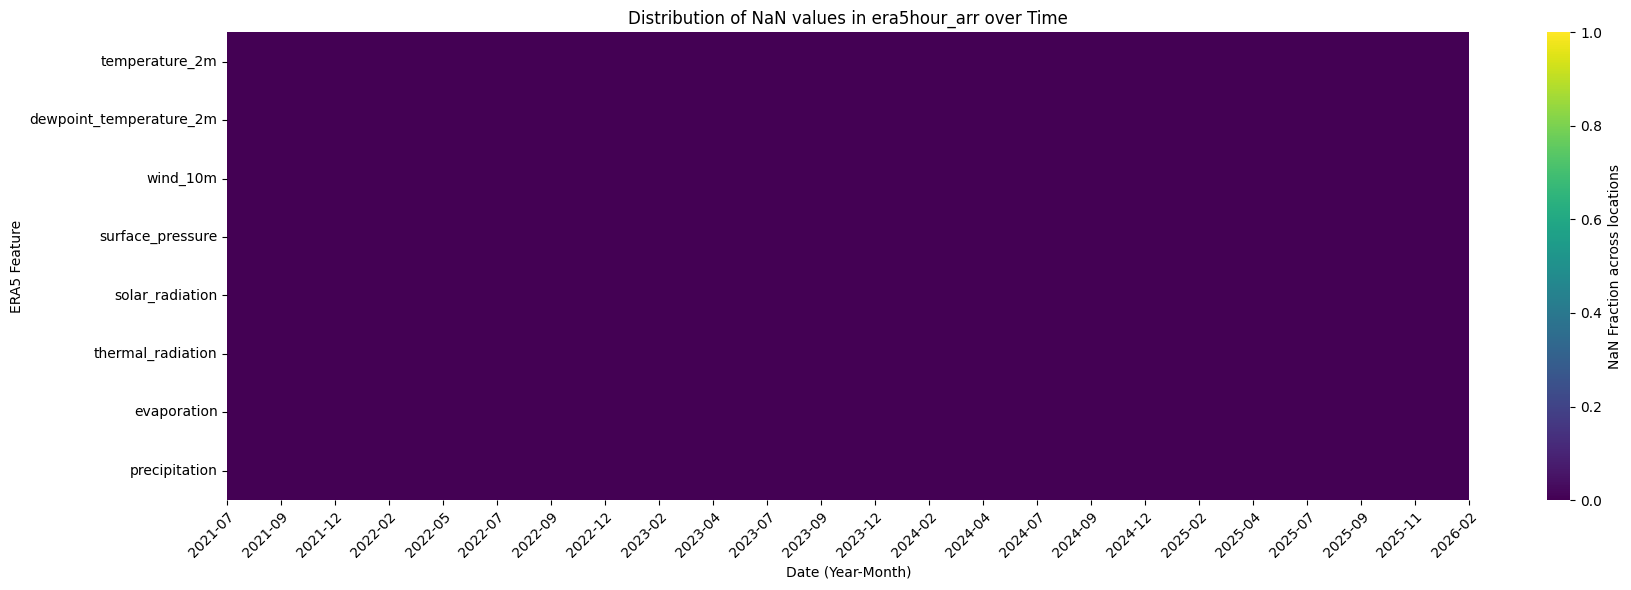

In [36]:
#@title plot ERA5 Nan Fraction (mean across sites) for each ERA5 var and timepoint
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Visualize NaN distribution over time across features (averaged over all locations)
# era5hour_arr shape: (features=8, time=40080, locations=79)
era5_nan_map = np.isnan(era5hour_arr).mean(axis=2)  # Shape (8, 40080)

feature_names = [
    'temperature_2m', 'dewpoint_temperature_2m', 'wind_10m', 'surface_pressure',
    'solar_radiation', 'thermal_radiation', 'evaporation', 'precipitation'
]

plt.figure(figsize=(18, 6))
ax = sns.heatmap(
    era5_nan_map, vmin=0, vmax=1, cmap='viridis',
    cbar_kws={'label': 'NaN Fraction across locations'},
)

# Calculate tick positions for dates
num_ticks = 24
tick_indices = np.linspace(0, len(datetime_list) - 1, num_ticks, dtype=int)
tick_labels = [datetime_list[i].strftime('%Y-%m') for i in tick_indices]

plt.xticks(ticks=tick_indices, labels=tick_labels, rotation=45, ha='right', rotation_mode='anchor')
plt.title('Distribution of NaN values in era5hour_arr over Time')
plt.xlabel('Date (Year-Month)')
plt.ylabel('ERA5 Feature')
plt.yticks(ticks=np.arange(8)+0.5, labels=feature_names, rotation=0)
plt.tight_layout()
plt.show()

In [37]:
start_datetime = datetime.strptime(start_date, '%Y-%m-%d')
end_datetime = datetime.strptime(end_date, '%Y-%m-%d')  # end_date
current_datetime = start_datetime
tfirsts = []
tlasts = []
deltaa = 15 # hours
while current_datetime < end_datetime:
  tfirsts.append(current_datetime)
  tlasts.append( current_datetime + timedelta(hours=deltaa))
  current_datetime += timedelta(hours=deltaa)

print(len(tfirsts))

2672


In [38]:
#@title Load any pre-saved Sentinel 1/2/HLSL30 data, check for nans, get missing tfirsts
from tqdm.auto import tqdm

Sentinel2_arr_filename = 'Sentinel2_arr_irriClimate.npy'
HLSL30_arr_filename = 'HLSL30_arr_irriClimate.npy'
sentinel1_arr_filename = 'sentinel1_arr_irriClimate.npy'
Sentinel2_npy_path = gdrive_data_dir / Sentinel2_arr_filename
if (gdrive_data_dir / Sentinel2_arr_filename).exists():
    print(f'loading pre-existing {Sentinel2_arr_filename}, {HLSL30_arr_filename}, {sentinel1_arr_filename}')
    Sentinel2_arr = np.load(gdrive_data_dir / Sentinel2_arr_filename)
    HLSL30_arr = np.load(gdrive_data_dir / HLSL30_arr_filename)
    sentinel1_arr = np.load(gdrive_data_dir / sentinel1_arr_filename)

    # 1. Find indices of NaNs
    tfirst_idxs = []
    for arr in [Sentinel2_arr, HLSL30_arr, sentinel1_arr]:
      nan_indices = np.where(np.isnan(arr))

      if nan_indices[0].size > 0:
          print(f"Found {nan_indices[0].size:,} NaN elements.")

          # 2. Extract unique time indices (axis 1)
          unique_nan_time_indices = np.unique(nan_indices[1])

          # 3. Calculate which 15-hour window (tfirst) each index belongs to
          # window_idx = floor(hours_since_start / deltaa)
          nan_window_indices = sorted(list(set(unique_nan_time_indices // deltaa)))

          # 4. Map back to actual tfirst datetimes
          # tfirsts = [tfirsts[i] for i in nan_window_indices if i < len(tfirsts)]
          tfirst_idxs.extend([i for i in nan_window_indices if i < len(tfirsts)])
          print(f"Need to re-run {len(tfirst_idxs)} time windows.")
      else:
          print("No NaNs detected.")

else:
    print("File not found. Initializing fresh.")

tfirst_idxs = sorted(list(set(tfirst_idxs)))
[tfirsts[tfirst_idx] for tfirst_idx in tfirst_idxs[:10]] # Show first few

loading pre-existing Sentinel2_arr_irriClimate.npy, HLSL30_arr_irriClimate.npy, sentinel1_arr_irriClimate.npy
Found 31,523,240 NaN elements.
Need to re-run 2672 time windows.
Found 28,447,326 NaN elements.
Need to re-run 5344 time windows.
Found 9,469,524 NaN elements.
Need to re-run 8016 time windows.


[datetime.datetime(2021, 7, 16, 0, 0),
 datetime.datetime(2021, 7, 16, 15, 0),
 datetime.datetime(2021, 7, 17, 6, 0),
 datetime.datetime(2021, 7, 17, 21, 0),
 datetime.datetime(2021, 7, 18, 12, 0),
 datetime.datetime(2021, 7, 19, 3, 0),
 datetime.datetime(2021, 7, 19, 18, 0),
 datetime.datetime(2021, 7, 20, 9, 0),
 datetime.datetime(2021, 7, 21, 0, 0),
 datetime.datetime(2021, 7, 21, 15, 0)]

In [39]:
# @title parallel processing  for HLSL30
import concurrent.futures


def process_day(idx, feature_collection_crop):
  print(f'is running the {idx}th group')
  tfirst = tfirsts[idx]
  tlast = tlasts[idx]

  HLSL30_sub = HLSL30.filterDate(tfirst, tlast)
  Sentinel2_sub = Sentinel2.filterDate(tfirst, tlast)
  sentinel1_sub = Sentinel1.filterDate(tfirst, tlast)

  def sample_with_time(image):
        samples = image.sampleRegions(
            collection=feature_collection_crop,
            scale=100
        )
        return samples.map(lambda f: f.set('system:time_start', image.get('system:time_start')))

  # sentinel2
  Sentinel2_sampled_points = Sentinel2_sub.map(sample_with_time).flatten()
  points_list = Sentinel2_sampled_points.getInfo()['features']
  data = [point['properties'] for point in points_list]
  df = pd.DataFrame(data)
  # print('sentinel2: ',len(df))
  if 'id_num' in df.columns:
    df['datetime'] = pd.to_datetime(df['system:time_start'], unit='ms')
    df['id_idx'] = [refer_id_idx_dict[id] for id in df['id_num'].tolist()]
    df['time_idx'] = ((df['datetime'] - start_datetime).dt.total_seconds() / 3600).astype(int)
    grouped_df = df.groupby(['time_idx', 'id_idx']).mean()
    indices = grouped_df.index.tolist()
    for idx in indices:
      Sentinel2_arr[0, idx[0], idx[1]] = grouped_df.loc[idx, 'B2']
      Sentinel2_arr[1, idx[0], idx[1]] = grouped_df.loc[idx, 'B3']
      Sentinel2_arr[2, idx[0], idx[1]] = grouped_df.loc[idx, 'B4']
      Sentinel2_arr[3, idx[0], idx[1]] = grouped_df.loc[idx, 'B5']
      Sentinel2_arr[4, idx[0], idx[1]] = grouped_df.loc[idx, 'B6']
      Sentinel2_arr[5, idx[0], idx[1]] = grouped_df.loc[idx, 'B7']
      Sentinel2_arr[6, idx[0], idx[1]] = grouped_df.loc[idx, 'B8']
      Sentinel2_arr[7, idx[0], idx[1]] = grouped_df.loc[idx, 'B8A']
      Sentinel2_arr[8, idx[0], idx[1]] = grouped_df.loc[idx, 'B11']
      Sentinel2_arr[9, idx[0], idx[1]] = grouped_df.loc[idx, 'B12']

  # hlsl30
  HLSL30_sampled_points = HLSL30_sub.map(sample_with_time).flatten()
  points_list = HLSL30_sampled_points.getInfo()['features']
  data = [point['properties'] for point in points_list]
  df = pd.DataFrame(data)
  # print('hlsl30: ',len(df))
  if 'id_num' in df.columns:
    df['datetime'] = pd.to_datetime(df['system:time_start'], unit='ms')
    df['id_idx'] = [refer_id_idx_dict[id] for id in df['id_num'].tolist()]
    df['time_idx'] = ((df['datetime'] - start_datetime).dt.total_seconds() / 3600).astype(int)
    grouped_df = df.groupby(['time_idx', 'id_idx']).mean()
    indices = grouped_df.index.tolist()
    for idx in indices:
      HLSL30_arr[0, idx[0], idx[1]] = grouped_df.loc[idx, 'B2']
      HLSL30_arr[1, idx[0], idx[1]] = grouped_df.loc[idx, 'B3']
      HLSL30_arr[2, idx[0], idx[1]] = grouped_df.loc[idx, 'B4']
      HLSL30_arr[3, idx[0], idx[1]] = grouped_df.loc[idx, 'B5']
      HLSL30_arr[4, idx[0], idx[1]] = grouped_df.loc[idx, 'B6']
      HLSL30_arr[5, idx[0], idx[1]] = grouped_df.loc[idx, 'B7']
      HLSL30_arr[6, idx[0], idx[1]] = grouped_df.loc[idx, 'B9']
      HLSL30_arr[7, idx[0], idx[1]] = grouped_df.loc[idx, 'B10']
      HLSL30_arr[8, idx[0], idx[1]] = grouped_df.loc[idx, 'B11']

  # sentinel1
  sentinel1_sampled_points = sentinel1_sub.map(sample_with_time).flatten()
  points_list = sentinel1_sampled_points.getInfo()['features']
  data = [point['properties'] for point in points_list]
  df = pd.DataFrame(data)
  # print('sentinel1: ',len(df))
  if 'id_num' in df.columns:
    df['datetime'] = pd.to_datetime(df['system:time_start'], unit='ms')
    df['id_idx'] = [refer_id_idx_dict[id] for id in df['id_num'].tolist()]
    df['time_idx'] = ((df['datetime'] - start_datetime).dt.total_seconds() / 3600).astype(int)
    grouped_df = df.groupby(['time_idx', 'id_idx']).mean()
    indices = grouped_df.index.tolist()
    for idx in indices:
      sentinel1_arr[0, idx[0], idx[1]] = grouped_df.loc[idx, 'VV']
      sentinel1_arr[1, idx[0], idx[1]] = grouped_df.loc[idx, 'VH']
      sentinel1_arr[2, idx[0], idx[1]] = grouped_df.loc[idx, 'angle']


  return idx



try:
  if not (
      np.isnan(Sentinel2_arr).any()
      or np.isnan(HLSL30_arr).any()
      or np.isnan(sentinel1_arr).any()
  ):
    print(f'no nans in Sentinel2/HLSL30/sentinel1 data, skipping download')
    pass
  # if os.path.exists('Sentinel2_arr_irriClimate.npy'):
  #   Sentinel2_arr = np.load('Sentinel2_arr_irriClimate.npy')
  #   HLSL30_arr = np.load('HLSL30_arr_irriClimate.npy')
  #   sentinel1_arr = np.load('sentinel1_arr_irriClimate.npy')
  else:
    with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
          # results = list(executor.map(lambda idx: process_day(idx, feature_collection), range(5050, len(tfirsts)))) # len(tfirsts)
          results = list(
              executor.map(
                  lambda idx: process_day(idx, feature_collection)
                  , range(len(tfirsts))
              )
          )
    print('done')

except Exception as main_error:
  print(f"🚨 Unexpected main error: {main_error}")
  traceback.print_exc()

finally:
  np.save(gdrive_data_dir / Sentinel2_arr_filename, Sentinel2_arr)
  np.save(gdrive_data_dir / HLSL30_arr_filename, HLSL30_arr)
  np.save(gdrive_data_dir / sentinel1_arr_filename, sentinel1_arr)
  print(f"Wrote {Sentinel2_arr_filename}, {HLSL30_arr_filename}, {sentinel1_arr_filename} to google drive.")
  # np.save('Sentinel2_arr_irriClimate.npy', Sentinel2_arr)
  # np.save('HLSL30_arr_irriClimate.npy', HLSL30_arr)
  # np.save('sentinel1_arr_irriClimate.npy', sentinel1_arr)

  # time.sleep(10)
  # from google.colab import files
  # files.download('Sentinel2_arr_irriClimate.npy')
  # files.download('HLSL30_arr_irriClimate.npy')
  # files.download('sentinel1_arr_irriClimate.npy')

is running the 0th groupis running the 1th group

is running the 2th group
is running the 3th group
is running the 4th group
is running the 5th group
is running the 6th group
is running the 7th group
is running the 8th group
is running the 9th group
is running the 10th group
is running the 11th group
is running the 12th group
is running the 13th group
is running the 14th group
is running the 15th group
is running the 16th group
is running the 17th group
is running the 18th group
is running the 19th group
is running the 20th group
is running the 21th group
is running the 22th group
is running the 23th group
is running the 24th group
is running the 25th group
is running the 26th group
is running the 27th group
is running the 28th group
is running the 29th group
is running the 30th group
is running the 31th group
is running the 32th group
is running the 33th group
is running the 34th group
is running the 35th group
is running the 36th group
is running the 37th group
is running the 38th gr

is running the 87th group
is running the 88th group
is running the 89th group


is running the 90th group
is running the 91th group
is running the 92th group
is running the 93th group
is running the 94th group
is running the 95th group
is running the 96th group
is running the 97th group
is running the 98th group
is running the 99th group


is running the 100th group
is running the 101th group
is running the 102th group
is running the 103th group
is running the 104th group
is running the 105th group
is running the 106th group
is running the 107th group
is running the 108th group
is running the 109th group
is running the 110th group
is running the 111th group
is running the 112th group


is running the 113th group


...

is running the 2560th group
is running the 2561th group
is running the 2562th group
is running the 2563th group
is running the 2564th group
is running the 2565th group
is running the 2566th group
is running the 2567th group
is running the 2568th group
is running the 2569th group
is running the 2570th group


is running the 2571th group
is running the 2572th group
is running the 2573th group
is running the 2574th group
is running the 2575th group
is running the 2576th group
is running the 2577th group
is running the 2578th group
is running the 2579th group
is running the 2580th group
is running the 2581th group
is running the 2582th group


is running the 2583th group
is running the 2584th group
is running the 2585th group
is running the 2586th group
is running the 2587th group
is running the 2588th group
is running the 2589th group
is running the 2590th group
is running the 2591th group
is running the 2592th group
is running the 2593th group
is running the 2594th group
is running the 2595th group
is running the 2596th group
is running the 2597th group
is running the 2598th group
is running the 2599th group
is running the 2600th group
is running the 2601th group
is running the 2602th group
is running the 2603th group
is running the 2604th group
is running the 2605th group
is running the 2606th group
is running the 2607th group
is running the 2608th group
is running the 2609th group
is running the 2610th group
is running the 2611th group
is running the 2612th group
is running the 2613th group


is running the 2614th group
is running the 2615th group
is running the 2616th group
is running the 2617th group
is running the 2618th group
is running the 2619th group
is running the 2620th group
is running the 2621th group
is running the 2622th group
is running the 2623th group
is running the 2624th group
is running the 2625th group
is running the 2626th group
is running the 2627th group
is running the 2628th group
is running the 2629th group
is running the 2630th group
is running the 2631th group
is running the 2632th group
is running the 2633th group
is running the 2634th group
is running the 2635th group
is running the 2636th group
is running the 2637th group
is running the 2638th group
is running the 2639th group
is running the 2640th group
is running the 2641th group
is running the 2642th group
is running the 2643th group
is running the 2644th group
is running the 2645th group
is running the 2646th group
is running the 2647th group
is running the 2648th group
is running the 2649t

is running the 2657th group
is running the 2658th group
is running the 2659th group
is running the 2660th group
is running the 2661th group
is running the 2662th group
is running the 2663th group
is running the 2664th group
is running the 2665th group
is running the 2666th group
is running the 2667th group
is running the 2668th group
is running the 2669th group
is running the 2670th group
is running the 2671th group
done
Wrote Sentinel2_arr_irriClimate.npy, HLSL30_arr_irriClimate.npy, sentinel1_arr_irriClimate.npy to google drive.


In [40]:
# Diagnostic cell: Check collection counts and mask severity
print(f"Checking availability for range: {start_date} to {end_date}")

def check_collection(collection, name):
    count = collection.size().getInfo()
    print(f"{name} collection size: {count} images")
    if count > 0:
        first_date = ee.Date(collection.first().get('system:time_start')).format('YYYY-MM-dd').getInfo()
        print(f"  - First available date in filtered collection: {first_date}")

check_collection(Sentinel1, 'Sentinel-1')
check_collection(Sentinel2, 'Sentinel-2')
check_collection(HLSL30, 'HLSL30')

# Check current non-nan counts in the arrays
print("\nCurrent data accumulation status:")
print(f"Sentinel-1 non-nans: {np.count_nonzero(~np.isnan(sentinel1_arr))}")
print(f"Sentinel-2 non-nans: {np.count_nonzero(~np.isnan(Sentinel2_arr))}")
print(f"HLSL30 non-nans:    {np.count_nonzero(~np.isnan(HLSL30_arr))}")

Checking availability for range: 2021-07-16 to 2026-02-10
Sentinel-1 collection size: 1514 images
  - First available date in filtered collection: 2021-07-18
Sentinel-2 collection size: 20920 images
  - First available date in filtered collection: 2021-07-17
HLSL30 collection size: 10940 images
  - First available date in filtered collection: 2021-07-22

Current data accumulation status:
Sentinel-1 non-nans: 29436
Sentinel-2 non-nans: 139960
HLSL30 non-nans:    49554


In [47]:

for name, arr in zip(['Sentinel-1', 'Sentinel-2', 'HLSL30'], [sentinel1_arr, Sentinel2_arr, HLSL30_arr]):
  total_elements = math.prod(arr.shape)
  non_nans = np.count_nonzero(~np.isnan(arr[:, :, :]))
  print(f"shape of {name} arr: {arr.shape}, total elements: {math.prod(arr.shape)}")
  print(f'{name} NON-nan numbers: {non_nans}')
  print(f"NON-nan %: {non_nans / total_elements * 100:.4f}")

# print(f"shape of HLSL30_arr: {HLSL30_arr.shape}, total elements: {math.prod(HLSL30_arr.shape)}")
# print('shape of sentinel1_arr: ',sentinel1_arr.shape)
# print('shape of Sentinel2_arr: ',Sentinel2_arr.shape)
# print('HLSL30 NON-nan numbers: ',np.count_nonzero(~np.isnan(HLSL30_arr[:, :, :]))) #77000
# print('Sent-1 NON-nan numbers: ',np.count_nonzero(~np.isnan(sentinel1_arr[:, :, :])))
# print('Sent-2 NON-nan numbers: ',np.count_nonzero(~np.isnan(Sentinel2_arr[:, :, :])))

shape of Sentinel-1 arr: (3, 40080, 79), total elements: 9498960
Sentinel-1 NON-nan numbers: 29436
NON-nan %: 0.3099
shape of Sentinel-2 arr: (10, 40080, 79), total elements: 31663200
Sentinel-2 NON-nan numbers: 139960
NON-nan %: 0.4420
shape of HLSL30 arr: (9, 40080, 79), total elements: 28496880
HLSL30 NON-nan numbers: 49554
NON-nan %: 0.1739


In [48]:
import pandas as pd

def audit_mask_impact(collection, roi, start_date, end_date, name):
    # Get raw collection count without masks
    raw_col = ee.ImageCollection(collection.filterBounds(roi).filterDate(start_date, end_date))
    raw_count = raw_col.size().getInfo()

    # Use the existing filtered/masked collections from your notebook
    if name == 'Sentinel-2': masked_col = Sentinel2
    elif name == 'HLSL30': masked_col = HLSL30
    elif name == 'Sentinel-1': masked_col = Sentinel1

    masked_count = masked_col.size().getInfo()

    print(f"--- {name} Audit ---")
    print(f"Raw images available: {raw_count}")
    print(f"Images remaining after quality masking: {masked_count}")
    if raw_count > 0:
        print(f"Survival rate: {masked_count/raw_count*100:.2f}%")
    print("\n")

audit_mask_impact(ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED"), roi, start_date, end_date, 'Sentinel-2')
audit_mask_impact(ee.ImageCollection("NASA/HLS/HLSL30/v002"), roi, start_date, end_date, 'HLSL30')
audit_mask_impact(ee.ImageCollection('COPERNICUS/S1_GRD'), roi, start_date, end_date, 'Sentinel-1')

--- Sentinel-2 Audit ---
Raw images available: 20920
Images remaining after quality masking: 20920
Survival rate: 100.00%


--- HLSL30 Audit ---
Raw images available: 10940
Images remaining after quality masking: 10940
Survival rate: 100.00%


--- Sentinel-1 Audit ---
Raw images available: 1978
Images remaining after quality masking: 1514
Survival rate: 76.54%




In [49]:
import pandas as pd

def detailed_s1_audit(points_fc, start, end):
    # Get the raw collection intersecting the points
    s1_col = ee.ImageCollection('COPERNICUS/S1_GRD') \
        .filterBounds(points_fc.geometry()) \
        .filterDate(start, end)

    # Count raw availability
    total_count = s1_col.size().getInfo()

    # Breakdown by Orbit Pass
    asc = s1_col.filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING')).size().getInfo()
    desc = s1_col.filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')).size().getInfo()

    # Breakdown by polarization availability
    vv_vh = s1_col.filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
                  .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')).size().getInfo()

    print(f"--- Sentinel-1 Detailed Availability Audit ---")
    print(f"Total S1 images in ROI/Period: {total_count}")
    print(f"Ascending passes: {asc}")
    print(f"Descending passes: {desc}")
    print(f"Images with both VV and VH: {vv_vh}")

    # Check for specific orbit overlap density
    orbits = s1_col.aggregate_array('relativeOrbitNumber_start').distinct().getInfo()
    print(f"Number of unique relative orbits covering points: {len(orbits)}")

    # Sample temporal spacing for the first point
    first_point = ee.Feature(points_fc.first()).geometry()
    point_times = s1_col.filterBounds(first_point).aggregate_array('system:time_start').getInfo()
    if point_times:
        dates = sorted([datetime.fromtimestamp(t/1000) for t in point_times])
        diffs = pd.Series(dates).diff().dropna()
        print(f"\nSample Revisit Interval (Point 0):")
        print(f"  - Mean interval: {diffs.mean()}")
        print(f"  - Median interval: {diffs.median()}")
        print(f"  - Max gap: {diffs.max()}")

detailed_s1_audit(feature_collection, start_date, end_date)

--- Sentinel-1 Detailed Availability Audit ---
Total S1 images in ROI/Period: 1598
Ascending passes: 1296
Descending passes: 302
Images with both VV and VH: 1311
Number of unique relative orbits covering points: 6

Sample Revisit Interval (Point 0):
  - Mean interval: 36 days 19:11:59.533333333
  - Median interval: 11 days 23:59:59
  - Max gap: 1211 days 23:59:33


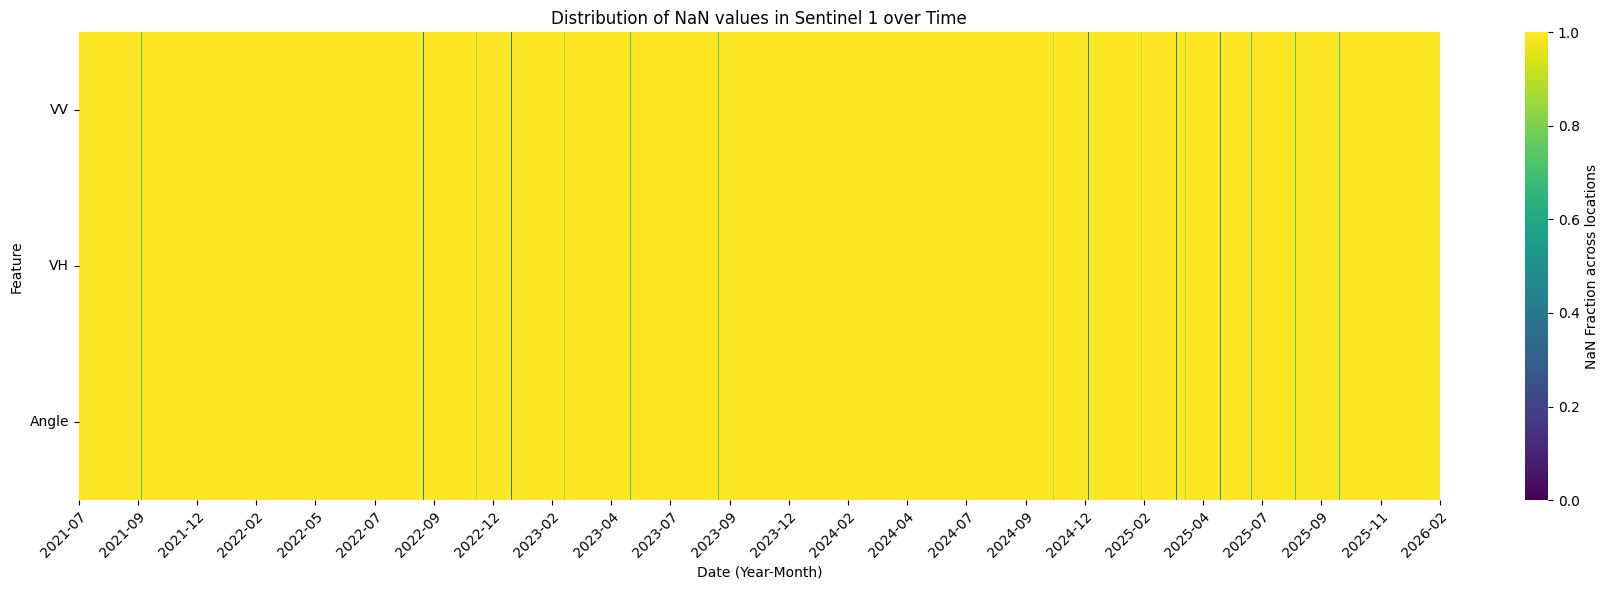

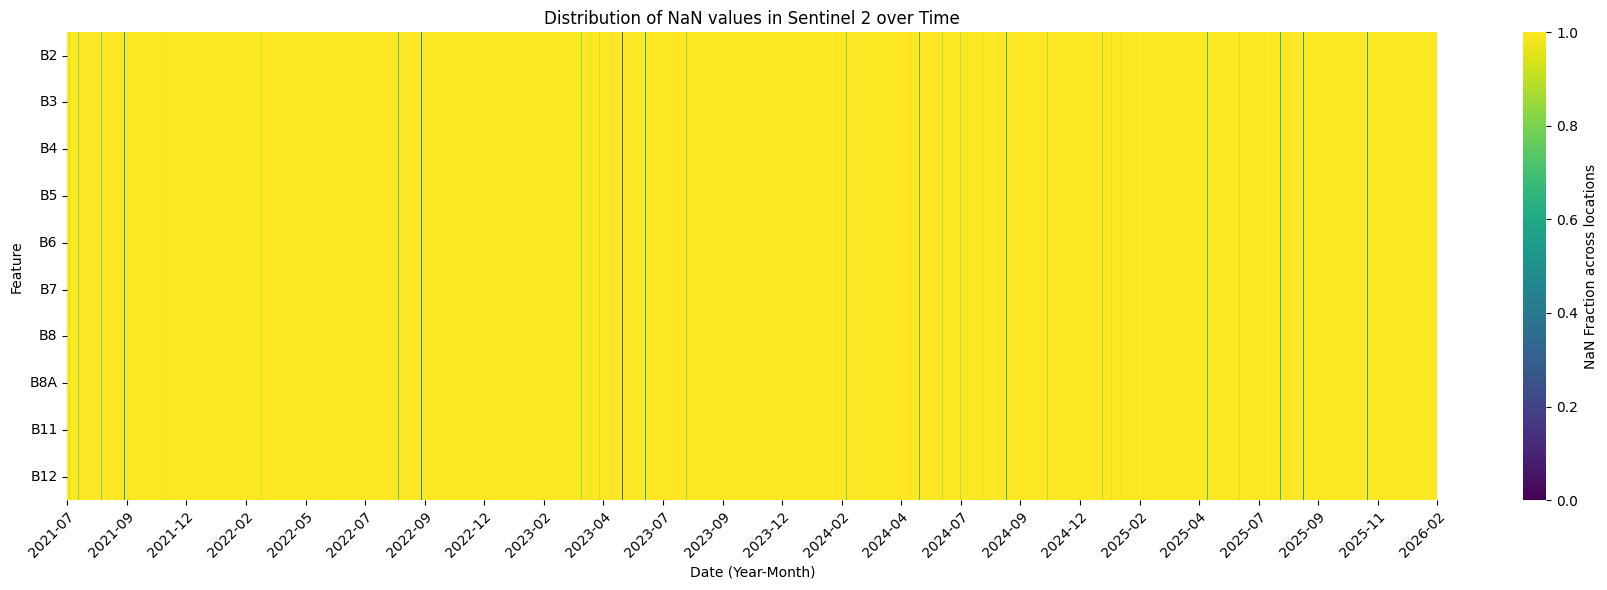

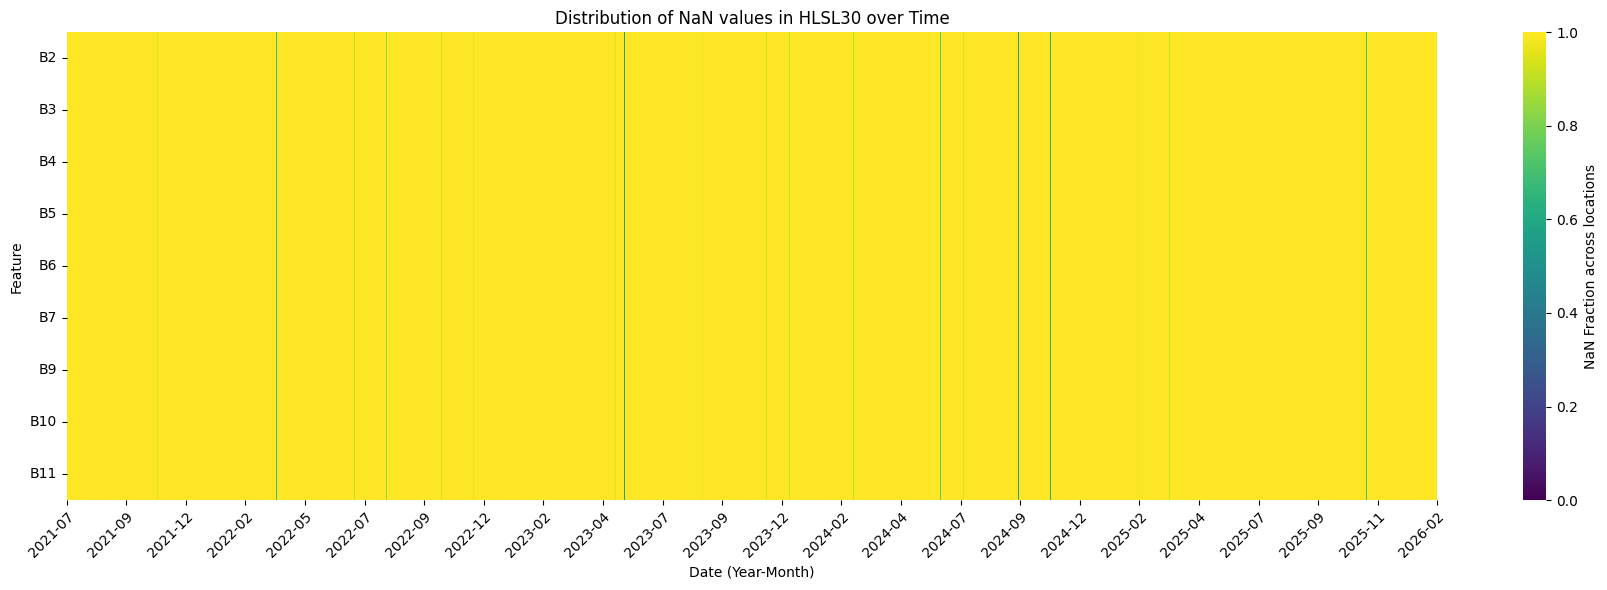

In [45]:
#@title plot sentinel data
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Visualize NaN distribution over time across features (averaged over all locations)
for arr, feature_names, title in zip(
    [sentinel1_arr, Sentinel2_arr, HLSL30_arr],
    [
        ["VV", "VH", "Angle"],
        ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"],
        ["B2", "B3", "B4", "B5", "B6", "B7", "B9", "B10", "B11"]
    ],
    ["Sentinel 1", "Sentinel 2", "HLSL30"],
):
  sat_nan_map = np.isnan(arr).mean(axis=2)  # Shape (8, 40080)

  plt.figure(figsize=(18, 6))
  ax = sns.heatmap(sat_nan_map, cmap='viridis', cbar_kws={'label': 'NaN Fraction across locations'}, vmax=1, vmin=0)

  # Calculate tick positions for dates (e.g., one tick per month or specific interval)
  # Using roughly 10 evenly spaced ticks for clarity across the 40,080 hours
  num_ticks = 24
  tick_indices = np.linspace(0, len(datetime_list) - 1, num_ticks, dtype=int)
  tick_labels = [datetime_list[i].strftime('%Y-%m') for i in tick_indices]

  plt.xticks(ticks=tick_indices, labels=tick_labels, rotation=45, ha='right', rotation_mode='anchor')
  plt.title(f'Distribution of NaN values in {title} over Time')
  plt.xlabel('Date (Year-Month)')
  plt.ylabel('Feature')
  plt.yticks(ticks=np.arange(len(feature_names))+0.5, labels=feature_names, rotation=0)
  plt.tight_layout()
  plt.show()

## ML model

In [165]:
# era5hour_arr = np.load('era5hour_arr_irriClimate.npy')  # loaded already (from gdrive)
print('shape of era5hour_arr: ',era5hour_arr.shape)
print('non-nan numbers: ', np.count_nonzero(~np.isnan(era5hour_arr)))

shape of era5hour_arr:  (8, 40080, 79)
non-nan numbers:  25330560


In [166]:
# @title ERA5 processing

#========================short term====================

ear5_d2m_arr_new = era5hour_arr[1, :, :].copy()
print(ear5_d2m_arr_new.shape)
ear5_t2m_arr_new = era5hour_arr[0, :, :].copy()
ear5_wind_arr_new = era5hour_arr[2, :, :].copy()
ear5_sp_arr_new = era5hour_arr[3, :, :].copy()
for row_idx in range(24, ear5_d2m_arr_new.shape[0]):
    ear5_d2m_arr_new[row_idx, :] = np.sum(era5hour_arr[1, row_idx - 23: row_idx + 1, :] * short_term_weights[:, np.newaxis], axis=0)
    ear5_t2m_arr_new[row_idx, :] = np.sum(era5hour_arr[0, row_idx - 23: row_idx + 1, :] * short_term_weights[:, np.newaxis], axis=0)
    ear5_wind_arr_new[row_idx, :] = np.sum(era5hour_arr[2, row_idx - 23: row_idx + 1, :] * short_term_weights[:, np.newaxis], axis=0)
    ear5_sp_arr_new[row_idx, :] = np.sum(era5hour_arr[3, row_idx - 23: row_idx + 1, :] * short_term_weights[:, np.newaxis], axis=0)


# ========================middle term====================

ear5_ssr_arr_new = era5hour_arr[4, :, :].copy()
ear5_str_arr_new = era5hour_arr[5, :, :].copy()
for row_idx in range(72, ear5_str_arr_new.shape[0]):
    ear5_ssr_arr_new[row_idx, :] = np.sum(era5hour_arr[4, row_idx - 71: row_idx + 1, :] * mid_term_weights[:, np.newaxis], axis=0)
    ear5_str_arr_new[row_idx, :] = np.sum(era5hour_arr[5, row_idx - 71: row_idx + 1, :] * mid_term_weights[:, np.newaxis], axis=0)


# ========================long term====================
ear5_e_arr_new = era5hour_arr[6, :, :].copy()
ear5_tp_arr_new = era5hour_arr[7, :, :].copy()
for row_idx in range(120, ear5_e_arr_new.shape[0]):
    ear5_e_arr_new[row_idx, :] = np.sum(era5hour_arr[6, row_idx - 119: row_idx + 1, :] * long_term_weights[:, np.newaxis] , axis=0)
    ear5_tp_arr_new[row_idx, :] = np.sum(era5hour_arr[7, row_idx - 119: row_idx + 1, :] * long_term_weights[:, np.newaxis], axis=0)

(40080, 79)


In [167]:
print('shape of ear5_d2m_arr_new: ',ear5_d2m_arr_new.shape)
print('shape of ear5_t2m_arr_new: ',ear5_t2m_arr_new.shape)
print('shape of ear5_wind_arr_new: ',ear5_wind_arr_new.shape)
print('shape of ear5_sp_arr_new: ',ear5_sp_arr_new.shape)
print('shape of ear5_ssr_arr_new: ',ear5_ssr_arr_new.shape)
print('shape of ear5_str_arr_new: ',ear5_str_arr_new.shape)
print('shape of ear5_e_arr_new: ',ear5_e_arr_new.shape)
print('shape of ear5_tp_arr_new: ',ear5_tp_arr_new.shape)

shape of ear5_d2m_arr_new:  (40080, 79)
shape of ear5_t2m_arr_new:  (40080, 79)
shape of ear5_wind_arr_new:  (40080, 79)
shape of ear5_sp_arr_new:  (40080, 79)
shape of ear5_ssr_arr_new:  (40080, 79)
shape of ear5_str_arr_new:  (40080, 79)
shape of ear5_e_arr_new:  (40080, 79)
shape of ear5_tp_arr_new:  (40080, 79)


In [168]:
#@title Remove inf values of Sentinel 1 - there are some but I do not know why
sentinel1_arr[sentinel1_arr>1000] = np.nan

In [169]:
referIDArr = df_random_points['ID'].to_numpy()
refer_lat_arr = df_random_points['latitude'].to_numpy()
refer_lon_arr = df_random_points['longitude'].to_numpy()

### SOMETHING GOES WRONG IN THIS CELL? FINAL SHAPE SEEMS WRONG.

In [170]:
# @title prepare Xy for ML and store them in npy file - sentinel1-rootzone
"""-------------------------------------sentinel1-rootzone--------------------------------------"""
# X - ID, year, doy, hour, latitude, longitude, dem, slope, sinAspect, cosAspect, TWI,
# bd, sand, clay, ksat, SMAP, d2m, t2m, ssr,str, e, wind, sp, tp,
# VV, VH, angle, CR,  DPSVIm, Pol  - 30
num_ids = len(refer_id_arr)
X = np.zeros((30, num_hours, num_ids))
X[:] = np.nan
X[0] = np.tile(referIDArr, (num_hours, 1))
X[1] = np.repeat(year_list[:, np.newaxis], num_ids, axis=1)
X[2] = np.repeat(doy_list[:, np.newaxis], num_ids, axis=1)
X[3] = np.repeat(hour_list[:, np.newaxis], num_ids, axis=1)
X[4] = np.tile(refer_lat_arr, (num_hours, 1))
X[5] = np.tile(refer_lon_arr, (num_hours, 1))
X[6] = np.tile(elevation_arr, (num_hours, 1))
X[7] = np.tile(slopeDegree_arr, (num_hours, 1))
X[8] = np.tile(sinAsp_arr, (num_hours, 1))
X[9] = np.tile(cosAsp_arr, (num_hours, 1))
X[10] = np.tile(TWII_arr, (num_hours, 1))
X[11] = np.tile(ml_bd_0_100, (num_hours, 1))
X[12] = np.tile(ml_sand_0_100, (num_hours, 1))
X[13] = np.tile(ml_clay_0_100, (num_hours, 1))
X[14] = np.tile(ml_ksat_0_100, (num_hours, 1))
X[15] = 0.3 # smap4_root_arr.T
X[16] = ear5_d2m_arr_new
X[17] = ear5_t2m_arr_new
X[18] = ear5_ssr_arr_new
X[19] = ear5_str_arr_new
X[20] = ear5_e_arr_new
X[21] = ear5_wind_arr_new
X[22] = ear5_sp_arr_new
X[23] = ear5_tp_arr_new
X[24] = sentinel1_arr[0, :, :]
X[25] = sentinel1_arr[1, :, :]
X[26] = sentinel1_arr[2, :, :]
X[27] = sentinel1_arr[0, :, :] / sentinel1_arr[1, :, :]
X[28] = (sentinel1_arr[0, :, :]**2 + sentinel1_arr[1, :, :]**2)/np.sqrt(2)
X[29] = (sentinel1_arr[0, :, :] + sentinel1_arr[1, :, :]) / (sentinel1_arr[0, :, :] - sentinel1_arr[1, :, :])

X = X.reshape((30, num_hours*num_ids))

X_mask = ~np.any(np.isnan(X), axis=0)


X_all = X[:, X_mask].T

print(f"sentinel1-rootzone {X_all.shape=}")
print(f"sentinel1-rootzone {np.count_nonzero(np.isnan(X_all))=}")

np.save('sentinel1_rootzone_X_all_CDL16_24.npy', X_all)

sentinel1-rootzone X_all.shape=(0, 30)
sentinel1-rootzone np.count_nonzero(np.isnan(X_all))=0


In [71]:
print(f"{X_mask.shape=}")
print(f"{X_mask=}")

X_mask.shape=(1896,)
X_mask=array([False, False, False, ..., False, False, False])


In [ ]:
# @title prepare Xy for ML and store them in npy file - sentinel1-surface
"""-------------------------------------sentinel1-surface--------------------------------------"""
# X - ID, year, doy, hour, latitude, longitude, dem, slope, sinAspect, cosAspect, TWI,
# bd, sand, clay, ksat, SMAP, d2m, t2m, ssr,str, e, wind, sp, tp,
# VV, VH, angle, CR,  DPSVIm, Pol  - 30
X = np.zeros((30, num_hours, num_ids))
X[:] = np.nan
X[0] = np.tile(referIDArr, (num_hours, 1))
X[1] = np.repeat(year_list[:, np.newaxis], num_ids, axis=1)
X[2] = np.repeat(doy_list[:, np.newaxis], num_ids, axis=1)
X[3] = np.repeat(hour_list[:, np.newaxis], num_ids, axis=1)
X[4] = np.tile(refer_lat_arr, (num_hours, 1))
X[5] = np.tile(refer_lon_arr, (num_hours, 1))
X[6] = np.tile(elevation_arr, (num_hours, 1))
X[7] = np.tile(slopeDegree_arr, (num_hours, 1))
X[8] = np.tile(sinAsp_arr, (num_hours, 1))
X[9] = np.tile(cosAsp_arr, (num_hours, 1))
X[10] = np.tile(TWII_arr, (num_hours, 1))
X[11] = np.tile(ml_bd_0_100, (num_hours, 1))
X[12] = np.tile(ml_sand_0_100, (num_hours, 1))
X[13] = np.tile(ml_clay_0_100, (num_hours, 1))
X[14] = np.tile(ml_ksat_0_100, (num_hours, 1))
X[15] = 0.3 #smap4_surface_arr.T
X[16] = ear5_d2m_arr_new
X[17] = ear5_t2m_arr_new
X[18] = ear5_ssr_arr_new
X[19] = ear5_str_arr_new
X[20] = ear5_e_arr_new
X[21] = ear5_wind_arr_new
X[22] = ear5_sp_arr_new
X[23] = ear5_tp_arr_new
X[24] = sentinel1_arr[0, :, :]
X[25] = sentinel1_arr[1, :, :]
X[26] = sentinel1_arr[2, :, :]
X[27] = sentinel1_arr[0, :, :] / sentinel1_arr[1, :, :]
X[28] = (sentinel1_arr[0, :, :] ** 2 + sentinel1_arr[1, :, :] ** 2) / np.sqrt(2)
X[29] = (sentinel1_arr[0, :, :] + sentinel1_arr[1, :, :]) / (sentinel1_arr[0, :, :] - sentinel1_arr[1, :, :])

X = X.reshape((30, num_hours * num_ids))

X_mask = ~np.any(np.isnan(X), axis=0)

X_all = X[:, X_mask].T

print(X_all.shape)
print(np.count_nonzero(np.isnan(X_all)))

np.save('sentinel1_surface_X_all_CDL16_24.npy', X_all)

In [48]:


# @title prepare Xy for ML and store them in npy file - sentinel2 etc.
"""-------------------------------------sentinel2-rootzone--------------------------------------"""
# X - ID, year, doy, hour, latitude, longitude, dem, slope, sinAspect, cosAspect, TWI,
# bd, sand, clay, ksat, SMAP, d2m, t2m, ssr,str, e, wind, sp, tp, - 24
# B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12, NDVI, NDWI, greenness, brightness, wetness  - 39
X = np.zeros((39, num_hours, num_ids))
X[:] = np.nan
X[0] = np.tile(referIDArr, (num_hours, 1))
X[1] = np.repeat(year_list[:, np.newaxis], num_ids, axis=1)
X[2] = np.repeat(doy_list[:, np.newaxis], num_ids, axis=1)
X[3] = np.repeat(hour_list[:, np.newaxis], num_ids, axis=1)
X[4] = np.tile(refer_lat_arr, (num_hours, 1))
X[5] = np.tile(refer_lon_arr, (num_hours, 1))
X[6] = np.tile(elevation_arr, (num_hours, 1))
X[7] = np.tile(slopeDegree_arr, (num_hours, 1))
X[8] = np.tile(sinAsp_arr, (num_hours, 1))
X[9] = np.tile(cosAsp_arr, (num_hours, 1))
X[10] = np.tile(TWII_arr, (num_hours, 1))
X[11] = np.tile(ml_bd_0_100, (num_hours, 1))
X[12] = np.tile(ml_sand_0_100, (num_hours, 1))
X[13] = np.tile(ml_clay_0_100, (num_hours, 1))
X[14] = np.tile(ml_ksat_0_100, (num_hours, 1))
X[15] = 0.3 #smap4_surface_arr.T
X[16] = ear5_d2m_arr_new
X[17] = ear5_t2m_arr_new
X[18] = ear5_ssr_arr_new
X[19] = ear5_str_arr_new
X[20] = ear5_e_arr_new
X[21] = ear5_wind_arr_new
X[22] = ear5_sp_arr_new
X[23] = ear5_tp_arr_new
X[24] = Sentinel2_arr[0, :, :] * 0.0001 # B2
X[25] = Sentinel2_arr[1, :, :] * 0.0001 # B3
X[26] = Sentinel2_arr[2, :, :] * 0.0001 # B4
X[27] = Sentinel2_arr[3, :, :] * 0.0001 # B5
X[28] = Sentinel2_arr[4, :, :] * 0.0001 # B6
X[29] = Sentinel2_arr[5, :, :] * 0.0001 # B7
X[30] = Sentinel2_arr[6, :, :] * 0.0001 # B8
X[31] = Sentinel2_arr[7, :, :] * 0.0001 # B8A
X[32] = Sentinel2_arr[8, :, :] * 0.0001 # B11
X[33] = Sentinel2_arr[9, :, :] * 0.0001 # B12
X[34] = (X[30] - X[26])/(X[30] + X[26])  # NDVI
X[35] = (X[25] - X[30])/(X[25] + X[30])  # NDWI
X[36] = -0.3599 * X[24] - 0.3533 * X[25] - 0.4734 * X[26] + 0.6633 * X[30] - 0.0087 * X[32] - 0.2856 * X[33] # greenness
X[37] = 0.3510 * X[24] + 0.3813 * X[25] + 0.3437 * X[26] + 0.7196 * X[30] + 0.2396 * X[32] + 0.1949 * X[33]  # brightness
X[38] = 0.2578 * X[24] + 0.2305 * X[25] + 0.0883 * X[26] + 0.1071 * X[30] - 0.7611 * X[32] - 0.5308 * X[33]  # wetness

print('sentinel2-rootzone')
print('mean NDVI: ', np.nanmean(X[34]))
print('mean NDWI: ', np.nanmean(X[35]))
print('mean greenness: ', np.nanmean(X[36]))
print('mean brightness: ', np.nanmean(X[37]))
print('mean wetness: ', np.nanmean(X[38]))

X = X.reshape((39, num_hours * num_ids))

y = np.zeros((num_hours, num_ids))

X_mask = ~np.any(np.isnan(X), axis=0)
y_mask = ~np.isnan(y[0])

X_all = X[:, X_mask].T

print(X_all.shape)
print(np.count_nonzero(np.isnan(X_all)))

np.save('sentinel2_rootzone_X_all_CDL16_24.npy', X_all)

"""-------------------------------------sentinel2-surface--------------------------------------"""
# X - ID, year, doy, hour, latitude, longitude, dem, slope, sinAspect, cosAspect, TWI,
# bd, sand, clay, ksat, SMAP, d2m, t2m, ssr,str, e, wind, sp, tp,- 24
#     # B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12, NDVI, NDWI, greenness, brightness, wetness  - 39
X = np.zeros((39, num_hours, num_ids))
X[:] = np.nan
X[0] = np.tile(referIDArr, (num_hours, 1))
X[1] = np.repeat(year_list[:, np.newaxis], num_ids, axis=1)
X[2] = np.repeat(doy_list[:, np.newaxis], num_ids, axis=1)
X[3] = np.repeat(hour_list[:, np.newaxis], num_ids, axis=1)
X[4] = np.tile(refer_lat_arr, (num_hours, 1))
X[5] = np.tile(refer_lon_arr, (num_hours, 1))
X[6] = np.tile(elevation_arr, (num_hours, 1))
X[7] = np.tile(slopeDegree_arr, (num_hours, 1))
X[8] = np.tile(sinAsp_arr, (num_hours, 1))
X[9] = np.tile(cosAsp_arr, (num_hours, 1))
X[10] = np.tile(TWII_arr, (num_hours, 1))
X[11] = np.tile(ml_bd_0_100, (num_hours, 1))
X[12] = np.tile(ml_sand_0_100, (num_hours, 1))
X[13] = np.tile(ml_clay_0_100, (num_hours, 1))
X[14] = np.tile(ml_ksat_0_100, (num_hours, 1))
X[15] = 0.3 #smap4_surface_arr.T
X[16] = ear5_d2m_arr_new
X[17] = ear5_t2m_arr_new
X[18] = ear5_ssr_arr_new
X[19] = ear5_str_arr_new
X[20] = ear5_e_arr_new
X[21] = ear5_wind_arr_new
X[22] = ear5_sp_arr_new
X[23] = ear5_tp_arr_new
X[24] = Sentinel2_arr[0, :, :] * 0.0001 # B2
X[25] = Sentinel2_arr[1, :, :] * 0.0001 # B3
X[26] = Sentinel2_arr[2, :, :] * 0.0001 # B4
X[27] = Sentinel2_arr[3, :, :] * 0.0001 # B5
X[28] = Sentinel2_arr[4, :, :] * 0.0001 # B6
X[29] = Sentinel2_arr[5, :, :] * 0.0001 # B7
X[30] = Sentinel2_arr[6, :, :] * 0.0001 # B8
X[31] = Sentinel2_arr[7, :, :] * 0.0001 # B8A
X[32] = Sentinel2_arr[8, :, :] * 0.0001 # B11
X[33] = Sentinel2_arr[9, :, :] * 0.0001 # B12
X[34] = (X[30] - X[26])/(X[30] + X[26])  # NDVI
X[35] = (X[25] - X[30])/(X[25] + X[30])  # NDWI
X[36] = -0.3599 * X[24] - 0.3533 * X[25] - 0.4734 * X[26] + 0.6633 * X[30] - 0.0087 * X[32] - 0.2856 * X[33] # greenness
X[37] = 0.3510 * X[24] + 0.3813 * X[25] + 0.3437 * X[26] + 0.7196 * X[30] + 0.2396 * X[32] + 0.1949 * X[33]  # brightness
X[38] = 0.2578 * X[24] + 0.2305 * X[25] + 0.0883 * X[26] + 0.1071 * X[30] - 0.7611 * X[32] - 0.5308 * X[33]  # wetness

print('sentinel2-surface')
print('mean NDVI: ', np.nanmean(X[34]))
print('mean NDWI: ', np.nanmean(X[35]))
print('mean greenness: ', np.nanmean(X[36]))
print('mean brightness: ', np.nanmean(X[37]))
print('mean wetness: ', np.nanmean(X[38]))

X = X.reshape((39, num_hours * num_ids))

X_mask = ~np.any(np.isnan(X), axis=0)

X_all = X[:, X_mask].T

print(X_all.shape)
print(np.count_nonzero(np.isnan(X_all)))

np.save('sentinel2_surface_X_all_CDL16_24.npy', X_all)

"""-------------------------------------HLSL30-rootzone--------------------------------------"""
# X - ID, year, doy, hour, latitude, longitude, dem, slope, sinAspect, cosAspect, TWI,
# bd, sand, clay, ksat, SMAP, d2m, t2m, ssr,str, e, wind, sp, tp, - 24
# B2, B3, B4, B5, B6, B7, B10, B11, SZA, SAA, VZA, VAA, NDVI, NDWI, greenness, brightness, wetness  - 41
X = np.zeros((41, num_hours, num_ids))
X[:] = np.nan
X[0] = np.tile(referIDArr, (num_hours, 1))
X[1] = np.repeat(year_list[:, np.newaxis], num_ids, axis=1)
X[2] = np.repeat(doy_list[:, np.newaxis], num_ids, axis=1)
X[3] = np.repeat(hour_list[:, np.newaxis], num_ids, axis=1)
X[4] = np.tile(refer_lat_arr, (num_hours, 1))
X[5] = np.tile(refer_lon_arr, (num_hours, 1))
X[6] = np.tile(elevation_arr, (num_hours, 1))
X[7] = np.tile(slopeDegree_arr, (num_hours, 1))
X[8] = np.tile(sinAsp_arr, (num_hours, 1))
X[9] = np.tile(cosAsp_arr, (num_hours, 1))
X[10] = np.tile(TWII_arr, (num_hours, 1))
X[11] = np.tile(ml_bd_0_100, (num_hours, 1))
X[12] = np.tile(ml_sand_0_100, (num_hours, 1))
X[13] = np.tile(ml_clay_0_100, (num_hours, 1))
X[14] = np.tile(ml_ksat_0_100, (num_hours, 1))
X[15] = 0.3 #smap4_surface_arr.T
X[16] = ear5_d2m_arr_new
X[17] = ear5_t2m_arr_new
X[18] = ear5_ssr_arr_new
X[19] = ear5_str_arr_new
X[20] = ear5_e_arr_new
X[21] = ear5_wind_arr_new
X[22] = ear5_sp_arr_new
X[23] = ear5_tp_arr_new
X[24] = HLSL30_arr[0, :, :]  # B2
X[25] = HLSL30_arr[1, :, :]   # B3
X[26] = HLSL30_arr[2, :, :]   # B4
X[27] = HLSL30_arr[3, :, :]   # B5
X[28] = HLSL30_arr[4, :, :]  # B6
X[29] = HLSL30_arr[5, :, :]   # B7
X[30] = HLSL30_arr[7, :, :]   # B10
X[31] = HLSL30_arr[8, :, :]   # B11
X[32] = 90 #HLSL30_arr[9, :, :]   # SZA
X[33] = 90 #HLSL30_arr[10, :, :]  # SAA
X[34] = 90 #HLSL30_arr[11, :, :]  # VZA
X[35] = 90 #HLSL30_arr[12, :, :]  # VAA
X[36] = (X[27] - X[26]) / (X[27] + X[26])  # NDVI
X[37] = (X[25] - X[27]) / (X[25] + X[27])  # NDWI
X[38] = -0.2941 * X[24] - 0.243 * X[25] - 0.5424 * X[26] +0.7276 * X[27] +0.0713 * X[28] - 0.1608 * X[29]  # greenness
X[39] = 0.3510 * X[24] + 0.3813 * X[25] + 0.3437 * X[26] + 0.7196 * X[27] + 0.2396 * X[28] + 0.1949 * X[29]  # brightness
X[40] = 0.2578 * X[24] + 0.2305 * X[25] + 0.0883 * X[26] + 0.1071 * X[27] - 0.7611 * X[28] - 0.5308 * X[29]  # wetness

print('HLSL30-rootzone')
print('mean NDVI: ', np.nanmean(X[36]))
print('mean NDWI: ', np.nanmean(X[37]))
print('mean greenness: ', np.nanmean(X[38]))
print('mean brightness: ', np.nanmean(X[39]))
print('mean wetness: ', np.nanmean(X[40]))

X = X.reshape((41, num_hours * num_ids))

X_mask = ~np.any(np.isnan(X), axis=0)

X_all = X[:, X_mask].T

print(X_all.shape)
print(np.count_nonzero(np.isnan(X_all)))

np.save('HLSL30_rootzone_X_all_CDL16_24.npy', X_all)

"""-------------------------------------HLSL30-surface--------------------------------------"""
# X - ID, year, doy, hour, latitude, longitude, dem, slope, sinAspect, cosAspect, TWI,
# bd, sand, clay, ksat, SMAP, d2m, t2m, ssr,str, e, wind, sp, tp,- 24
#    B2, B3, B4, B5, B6, B7, B10, B11, SZA, SAA, VZA, VAA, NDVI, NDWI, greenness, brightness, wetness  - 41
X = np.zeros((41, num_hours, num_ids))
X[:] = np.nan
X[0] = np.tile(referIDArr, (num_hours, 1))
X[1] = np.repeat(year_list[:, np.newaxis], num_ids, axis=1)
X[2] = np.repeat(doy_list[:, np.newaxis], num_ids, axis=1)
X[3] = np.repeat(hour_list[:, np.newaxis], num_ids, axis=1)
X[4] = np.tile(refer_lat_arr, (num_hours, 1))
X[5] = np.tile(refer_lon_arr, (num_hours, 1))
X[6] = np.tile(elevation_arr, (num_hours, 1))
X[7] = np.tile(slopeDegree_arr, (num_hours, 1))
X[8] = np.tile(sinAsp_arr, (num_hours, 1))
X[9] = np.tile(cosAsp_arr, (num_hours, 1))
X[10] = np.tile(TWII_arr, (num_hours, 1))
X[11] = np.tile(ml_bd_0_100, (num_hours, 1))
X[12] = np.tile(ml_sand_0_100, (num_hours, 1))
X[13] = np.tile(ml_clay_0_100, (num_hours, 1))
X[14] = np.tile(ml_ksat_0_100, (num_hours, 1))
X[15] = 0.3 #smap4_surface_arr.T
X[16] = ear5_d2m_arr_new
X[17] = ear5_t2m_arr_new
X[18] = ear5_ssr_arr_new
X[19] = ear5_str_arr_new
X[20] = ear5_e_arr_new
X[21] = ear5_wind_arr_new
X[22] = ear5_sp_arr_new
X[23] = ear5_tp_arr_new
X[24] = HLSL30_arr[0, :, :]  # B2
X[25] = HLSL30_arr[1, :, :]  # B3
X[26] = HLSL30_arr[2, :, :]  # B4
X[27] = HLSL30_arr[3, :, :]  # B5
X[28] = HLSL30_arr[4, :, :]  # B6
X[29] = HLSL30_arr[5, :, :]  # B7
X[30] = HLSL30_arr[7, :, :] # B10
X[31] = HLSL30_arr[8, :, :]  # B11
X[32] = 90 #HLSL30_arr[9, :, :]  # SZA
X[33] = 90 #HLSL30_arr[10, :, :]  # SAA
X[34] = 90 #HLSL30_arr[11, :, :]  # VZA
X[35] = 90 #HLSL30_arr[12, :, :]  # VAA
X[36] = (X[27] - X[26]) / (X[27] + X[26])  # NDVI
X[37] = (X[25] - X[27]) / (X[25] + X[27])  # NDWI
X[38] = -0.2941 * X[24] - 0.243 * X[25] - 0.5424 * X[26] +0.7276 * X[27] +0.0713 * X[28] - 0.1608 * X[29]  # greenness
X[39] = 0.3510 * X[24] + 0.3813 * X[25] + 0.3437 * X[26] + 0.7196 * X[27] + 0.2396 * X[28] + 0.1949 * X[29]  # brightness
X[40] = 0.2578 * X[24] + 0.2305 * X[25] + 0.0883 * X[26] + 0.1071 * X[27] - 0.7611 * X[28] - 0.5308 * X[29]  # wetness

print('HLSL30-surface')
print('mean NDVI: ', np.nanmean(X[36]))
print('mean NDWI: ', np.nanmean(X[37]))
print('mean greenness: ', np.nanmean(X[38]))
print('mean brightness: ', np.nanmean(X[39]))
print('mean wetness: ', np.nanmean(X[40]))

X = X.reshape((41, num_hours * num_ids))

X_mask = ~np.any(np.isnan(X), axis=0)

X_all = X[:, X_mask].T

print(X_all.shape)
print(np.count_nonzero(np.isnan(X_all)))

np.save('HLSL30_surface_X_all_CDL16_24.npy', X_all)


print()

(0, 30)
0
(0, 30)
0
sentinel2-rootzone
mean NDVI:  nan
mean NDWI:  nan
mean greenness:  nan
mean brightness:  nan
mean wetness:  nan
(0, 39)
0
sentinel2-surface
mean NDVI:  nan
mean NDWI:  nan
mean greenness:  nan
mean brightness:  nan
mean wetness:  nan
(0, 39)
0
HLSL30-rootzone
mean NDVI:  nan
mean NDWI:  nan
mean greenness:  nan
mean brightness:  nan
mean wetness:  nan
(0, 41)
0
HLSL30-surface
mean NDVI:  nan
mean NDWI:  nan
mean greenness:  nan
mean brightness:  nan
mean wetness:  nan
(0, 41)
0



In [49]:
from google.colab import files
import os

# List all files in the current directory (root folder)
files_to_download = [f for f in os.listdir('.') if os.path.isfile(f) and f.endswith(('y_CDL16_24.npy', '_X_valid.npy', '_y_valid.npy'))]

for file_name in files_to_download:
  try:
    files.download(file_name)
  except Exception as e:
    print(f"Error downloading {file_name}: {e}")

In [50]:
np.set_printoptions(suppress=True, precision=6, floatmode='fixed')

HLSL30_surface_X_all = np.load('HLSL30_surface_X_all_CDL16_24.npy')
print(np.nanmean(HLSL30_surface_X_all, axis=0))
HLSL30_rootzone_X_all = np.load('HLSL30_rootzone_X_all_CDL16_24.npy')
print(np.nanmean(HLSL30_rootzone_X_all, axis=0))
sentinel2_rootzone_X_all = np.load('sentinel2_rootzone_X_all_CDL16_24.npy')
print(np.nanmean(sentinel2_rootzone_X_all, axis=0))
sentinel2_surface_X_all = np.load('sentinel2_surface_X_all_CDL16_24.npy')
print(np.nanmean(sentinel2_surface_X_all, axis=0))
sentinel1_rootzone_X_all = np.load('sentinel1_rootzone_X_all_CDL16_24.npy')
print(np.nanmean(sentinel1_rootzone_X_all, axis=0))
sentinel1_surface_X_all = np.load('sentinel1_surface_X_all_CDL16_24.npy')
print(np.nanmean(sentinel1_surface_X_all, axis=0))

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]


## run ML models

In [51]:
!git clone https://github.com/ilmcconnell/HRSM.git
!cd HRSM && git checkout ilm-wisconet

fatal: destination path 'HRSM' already exists and is not an empty directory.
Already on 'ilm-wisconet'
Your branch is up to date with 'origin/ilm-wisconet'.


In [58]:
! ls -lsh ./HRSM/trainedML/

total 95M
9.5M -rw-r--r-- 1 root root 9.5M May 23 19:29 ML1_rly_lgb_mean.joblib
 31M -rw-r--r-- 1 root root  31M May 23 19:29 ML1_rly_mapie_cqr.joblib
4.0K -rw-r--r-- 1 root root 1.3K May 23 19:29 ML1_rly_scaler.joblib
5.8M -rw-r--r-- 1 root root 5.8M May 23 19:29 ML1_sly_lgb_mean.joblib
 19M -rw-r--r-- 1 root root  19M May 23 19:29 ML1_sly_mapie_cqr.joblib
4.0K -rw-r--r-- 1 root root 1.3K May 23 19:29 ML1_sly_scaler.joblib
416K -rw-r--r-- 1 root root 415K May 23 19:29 ML2_rly_lgb_mean.joblib
1.4M -rw-r--r-- 1 root root 1.4M May 23 19:29 ML2_rly_mapie_cqr.joblib
4.0K -rw-r--r-- 1 root root 1.4K May 23 19:29 ML2_rly_scaler.joblib
1.4M -rw-r--r-- 1 root root 1.4M May 23 19:29 ML2_sly_lgb_mean.joblib
4.4M -rw-r--r-- 1 root root 4.4M May 23 19:29 ML2_sly_mapie_cqr.joblib
4.0K -rw-r--r-- 1 root root 1.4K May 23 19:29 ML2_sly_scaler.joblib
3.1M -rw-r--r-- 1 root root 3.1M May 23 19:29 ML3_rly_lgb_mean.joblib
9.2M -rw-r--r-- 1 root root 9.2M May 23 19:29 ML3_rly_mapie_cqr.joblib
4.0K -rw-r--r

In [52]:
# Load ML models from repo

In [59]:

#@title Load ML models - this is the ML models from the HRSM repo
ML1_sly_scaler = joblib.load('./HRSM/trainedML/ML1_sly_scaler.joblib')
ML1_rly_scaler = joblib.load('./HRSM/trainedML/ML1_rly_scaler.joblib')
ML2_sly_scaler = joblib.load('./HRSM/trainedML/ML2_sly_scaler.joblib')
ML2_rly_scaler = joblib.load('./HRSM/trainedML/ML2_rly_scaler.joblib')
ML3_sly_scaler = joblib.load('./HRSM/trainedML/ML3_sly_scaler.joblib')
ML3_rly_scaler = joblib.load('./HRSM/trainedML/ML3_rly_scaler.joblib')
# ML1-sly
ML1_sly_lgb_mean = joblib.load('./HRSM/trainedML/ML1_sly_lgb_mean.joblib')
ML1_sly_mapie_cqr = joblib.load('./HRSM/trainedML/ML1_sly_mapie_cqr.joblib')
# ML1 - rly
ML1_rly_lgb_mean = joblib.load('./HRSM/trainedML/ML1_rly_lgb_mean.joblib')
ML1_rly_mapie_cqr = joblib.load('./HRSM/trainedML/ML1_rly_mapie_cqr.joblib')
# ML2-sly
ML2_sly_lgb_mean = joblib.load('./HRSM/trainedML/ML2_sly_lgb_mean.joblib')
ML2_sly_mapie_cqr = joblib.load('./HRSM/trainedML/ML2_sly_mapie_cqr.joblib')
# ML2-rly
ML2_rly_lgb_mean = joblib.load('./HRSM/trainedML/ML2_rly_lgb_mean.joblib')
ML2_rly_mapie_cqr = joblib.load('./HRSM/trainedML/ML2_rly_mapie_cqr.joblib')
# ML3-sly
ML3_sly_lgb_mean = joblib.load('./HRSM/trainedML/ML3_sly_lgb_mean.joblib')
ML3_sly_mapie_cqr = joblib.load('./HRSM/trainedML/ML3_sly_mapie_cqr.joblib')
# ML3-rly
ML3_rly_lgb_mean = joblib.load('./HRSM/trainedML/ML3_rly_lgb_mean.joblib')
ML3_rly_mapie_cqr = joblib.load('./HRSM/trainedML/ML3_rly_mapie_cqr.joblib')

In [4]:
# #@title Load ML models - this is the ML models we trained in HRSM_MAPPING_Sec1_ML_ParameterTune_Validation_Train.ipynb
# ML1_sly_scaler = joblib.load('./StartFolder/TrainedML/ML1_sly_scaler.joblib')
# ML1_rly_scaler = joblib.load('./StartFolder/TrainedML/ML1_rly_scaler.joblib')
# ML2_sly_scaler = joblib.load('./StartFolder/TrainedML/ML2_sly_scaler.joblib')
# ML2_rly_scaler = joblib.load('./StartFolder/TrainedML/ML2_rly_scaler.joblib')
# ML3_sly_scaler = joblib.load('./StartFolder/TrainedML/ML3_sly_scaler.joblib')
# ML3_rly_scaler = joblib.load('./StartFolder/TrainedML/ML3_rly_scaler.joblib')
# # ML1-sly
# ML1_sly_lgb_mean = joblib.load('./StartFolder/TrainedML/ML1_sly_lgb_mean.joblib')
# ML1_sly_mapie_cqr = joblib.load('./StartFolder/TrainedML/ML1_sly_mapie_cqr.joblib')
# # ML1 - rly
# ML1_rly_lgb_mean = joblib.load('./StartFolder/TrainedML/ML1_rly_lgb_mean.joblib')
# ML1_rly_mapie_cqr = joblib.load('./StartFolder/TrainedML/ML1_rly_mapie_cqr.joblib')
# # ML2-sly
# ML2_sly_lgb_mean = joblib.load('./StartFolder/TrainedML/ML2_sly_lgb_mean.joblib')
# ML2_sly_mapie_cqr = joblib.load('./StartFolder/TrainedML/ML2_sly_mapie_cqr.joblib')
# # ML2-rly
# ML2_rly_lgb_mean = joblib.load('./StartFolder/TrainedML/ML2_rly_lgb_mean.joblib')
# ML2_rly_mapie_cqr = joblib.load('./StartFolder/TrainedML/ML2_rly_mapie_cqr.joblib')
# # ML3-sly
# ML3_sly_lgb_mean = joblib.load('./StartFolder/TrainedML/ML3_sly_lgb_mean.joblib')
# ML3_sly_mapie_cqr = joblib.load('./StartFolder/TrainedML/ML3_sly_mapie_cqr.joblib')
# # ML3-rly
# ML3_rly_lgb_mean = joblib.load('./StartFolder/TrainedML/ML3_rly_lgb_mean.joblib')
# ML3_rly_mapie_cqr = joblib.load('./StartFolder/TrainedML/ML3_rly_mapie_cqr.joblib')

In [60]:
removed_indices_ML1 = [0, 1, 3, 15]
removed_indices_ML2 = [0, 1, 3, 15, 24, 25, 26]  # remove B2, B3, B4
removed_indices_ML3 = [0, 1, 3, 15, 24, 25, 26, 32, 33, 34, 35]  # remove B2, B3, B4, SZA, SAA, VZA, VAA, 32, 33, 34, 35


sentinel1_surface_X_all = np.delete(sentinel1_surface_X_all, removed_indices_ML1, axis=1)  #, 15
sentinel2_surface_X_all = np.delete(sentinel2_surface_X_all, removed_indices_ML2, axis=1)
HLSL30_surface_X_all = np.delete(HLSL30_surface_X_all, removed_indices_ML3, axis=1)
sentinel1_rootzone_X_all = np.delete(sentinel1_rootzone_X_all, removed_indices_ML1, axis=1)
sentinel2_rootzone_X_all = np.delete(sentinel2_rootzone_X_all, removed_indices_ML2, axis=1)
HLSL30_rootzone_X_all = np.delete(HLSL30_rootzone_X_all, removed_indices_ML3, axis=1)

print(sentinel1_surface_X_all.shape)
print(sentinel2_surface_X_all.shape)
print(HLSL30_surface_X_all.shape)
print(sentinel1_rootzone_X_all.shape)
print(sentinel2_rootzone_X_all.shape)
print(HLSL30_rootzone_X_all.shape)
#

(0, 26)
(0, 32)
(0, 30)
(0, 26)
(0, 32)
(0, 30)


In [61]:
sentinel1_surface_X_all = ML1_sly_scaler.transform(sentinel1_surface_X_all)
sentinel1_rootzone_X_all = ML1_rly_scaler.transform(sentinel1_rootzone_X_all)
sentinel2_surface_X_all = ML2_sly_scaler.transform(sentinel2_surface_X_all)
sentinel2_rootzone_X_all = ML2_rly_scaler.transform(sentinel2_rootzone_X_all)
HLSL30_surface_X_all = ML3_sly_scaler.transform(HLSL30_surface_X_all)
HLSL30_rootzone_X_all = ML3_rly_scaler.transform(HLSL30_rootzone_X_all)

sentinel1_surface_y = ML1_sly_lgb_mean.predict(sentinel1_surface_X_all)
sentinel1_rootzone_y = ML1_rly_lgb_mean.predict(sentinel1_rootzone_X_all)
sentinel2_surface_y = ML2_sly_lgb_mean.predict(sentinel2_surface_X_all)
sentinel2_rootzone_y = ML2_rly_lgb_mean.predict(sentinel2_rootzone_X_all)
HLSL30_surface_y = ML3_sly_lgb_mean.predict(HLSL30_surface_X_all)
HLSL30_rootzone_y = ML3_rly_lgb_mean.predict(HLSL30_rootzone_X_all)

ValueError: Found array with 0 sample(s) (shape=(0, 26)) while a minimum of 1 is required by StandardScaler.

In [ ]:
print(sentinel1_surface_y.shape)
print(sentinel1_rootzone_y.shape)
print(sentinel2_surface_y.shape)
print(sentinel2_rootzone_y.shape)
print(HLSL30_surface_y.shape)
print(HLSL30_rootzone_y.shape)
#

In [ ]:
np.save('sentinel1_surface_y_CDL16_24.npy', sentinel1_surface_y)
np.save('sentinel1_rootzone_y_CDL16_24.npy', sentinel1_rootzone_y)
np.save('sentinel2_surface_y_CDL16_24.npy', sentinel2_surface_y)
np.save('sentinel2_rootzone_y_CDL16_24.npy', sentinel2_rootzone_y)
np.save('HLSL30_surface_y_CDL16_24.npy', HLSL30_surface_y)
np.save('HLSL30_rootzone_y_CDL16_24.npy', HLSL30_rootzone_y)
#

## post-process predictions

In [ ]:
import numpy as np

# Load the saved arrays
sentinel1_surface_y_CDL16_24 = np.load('sentinel1_surface_y_CDL16_24.npy')
sentinel1_rootzone_y_CDL16_24 = np.load('sentinel1_rootzone_y_CDL16_24.npy')
sentinel2_surface_y_CDL16_24 = np.load('sentinel2_surface_y_CDL16_24.npy')
sentinel2_rootzone_y_CDL16_24 = np.load('sentinel2_rootzone_y_CDL16_24.npy')
HLSL30_surface_y_CDL16_24 = np.load('HLSL30_surface_y_CDL16_24.npy')
HLSL30_rootzone_y_CDL16_24 = np.load('HLSL30_rootzone_y_CDL16_24.npy')
#
sentinel1_surface_X_all_CDL16_24 = np.load('sentinel1_surface_X_all_CDL16_24.npy')
sentinel1_rootzone_X_all_CDL16_24 = np.load('sentinel1_rootzone_X_all_CDL16_24.npy')
sentinel2_surface_X_all_CDL16_24 = np.load('sentinel2_surface_X_all_CDL16_24.npy')
sentinel2_rootzone_X_all_CDL16_24 = np.load('sentinel2_rootzone_X_all_CDL16_24.npy')
HLSL30_surface_X_all_CDL16_24 = np.load('HLSL30_surface_X_all_CDL16_24.npy')
HLSL30_rootzone_X_all_CDL16_24 = np.load('HLSL30_rootzone_X_all_CDL16_24.npy')
#
print('sentinel1_surface_y_CDL16_24.shape: ', sentinel1_surface_y_CDL16_24.shape)
print('sentinel1_rootzone_y_CDL16_24.shape: ', sentinel1_rootzone_y_CDL16_24.shape)
print('sentinel2_surface_y_CDL16_24.shape: ', sentinel2_surface_y_CDL16_24.shape)
print('sentinel2_rootzone_y_CDL16_24.shape: ', sentinel2_rootzone_y_CDL16_24.shape)
print('HLSL30_surface_y_CDL16_24.shape: ', HLSL30_surface_y_CDL16_24.shape)
print('HLSL30_rootzone_y_CDL16_24.shape: ', HLSL30_rootzone_y_CDL16_24.shape)
#
print('sentinel1_surface_X_all_CDL16_24.shape: ', sentinel1_surface_X_all_CDL16_24.shape)
print('sentinel1_rootzone_X_all_CDL16_24.shape: ', sentinel1_rootzone_X_all_CDL16_24.shape)
print('sentinel2_surface_X_all_CDL16_24.shape: ', sentinel2_surface_X_all_CDL16_24.shape)
print('sentinel2_rootzone_X_all_CDL16_24.shape: ', sentinel2_rootzone_X_all_CDL16_24.shape)
print('HLSL30_surface_X_all_CDL16_24.shape: ', HLSL30_surface_X_all_CDL16_24.shape)
print('HLSL30_rootzone_X_all_CDL16_24.shape: ', HLSL30_rootzone_X_all_CDL16_24.shape)
#

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example: if your array is already defined
# sentinel1_surface_y_CDL16_24 = np.load('your_array.npy')

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(HLSL30_surface_y_CDL16_24, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Sentinel-1 Surface Values (CDL16_24)', fontsize=14)
plt.grid(alpha=0.4)
plt.show()

In [ ]:
#@title Re-organize to dataframe

# reorganize to 2-d array:
def get_time_index(initial_date, target_date):
    return int((target_date - initial_date).total_seconds() / 3600)

def DoY2Date(year, doy, hh=10):
    base_date = datetime(year, 1, 1, hour=hh)
    target_date = base_date + timedelta(days=(doy - 1))
    return target_date



def cdf_matching(source, target):
    sorted_target = np.sort(target)  # Target distribution sorted
    sorted_target_ranks = rankdata(sorted_target, method='average')
    sorted_target_quantiles = sorted_target_ranks / len(sorted_target)
    ranks = rankdata(source, method='average')  # Source data ranks
    percentiles = ranks / len(source)  # Percentile positions of source data
    matched_values = np.interp(percentiles, sorted_target_quantiles, sorted_target)  # Interpolation
    return matched_values



def CDF_maptching_and_reorganize_arr(ML1_sly_y_pred_all_arr, ML2_sly_y_pred_all_arr, ML3_sly_y_pred_all_arr, ML1_sly_info_arr, ML2_sly_info_arr, ML3_sly_info_arr, refer_id_arr):


    refer_id_idx_dict = {}
    for i in range(len(refer_id_arr)):
      refer_id_idx_dict[refer_id_arr[i]] = i


    ids = refer_id_arr
    len_id = len(ids)

    num_hours = 78192

    ML_sly_y_pred_arr = np.zeros((4, num_hours, len_id))
    ML_sly_y_pred_arr[:] = np.nan

    start_time = datetime(2016, 1, 1, 0)

    for i in range(len(ML1_sly_y_pred_all_arr)):
      t_idx = get_time_index(start_time, DoY2Date(int(ML1_sly_info_arr[i,  1]), int(ML1_sly_info_arr[i, 2]), int(ML1_sly_info_arr[i, 3])))
      id_idx = refer_id_idx_dict[int(ML1_sly_info_arr[i, 0])]
      ML_sly_y_pred_arr[0, t_idx, id_idx] = ML1_sly_y_pred_all_arr[i]


    for i in range(len(ML2_sly_y_pred_all_arr)):
      t_idx = get_time_index(start_time, DoY2Date(int(ML2_sly_info_arr[i,  1]), int(ML2_sly_info_arr[i, 2]), int(ML2_sly_info_arr[i, 3])))
      id_idx = refer_id_idx_dict[int(ML2_sly_info_arr[i, 0])]
      ML_sly_y_pred_arr[1, t_idx, id_idx] = ML2_sly_y_pred_all_arr[i]


    for i in range(len(ML3_sly_y_pred_all_arr)):
      t_idx = get_time_index(start_time, DoY2Date(int(ML3_sly_info_arr[i,  1]), int(ML3_sly_info_arr[i, 2]), int(ML3_sly_info_arr[i, 3])))
      id_idx = refer_id_idx_dict[int(ML3_sly_info_arr[i, 0])]
      ML_sly_y_pred_arr[2, t_idx, id_idx] = ML3_sly_y_pred_all_arr[i]


    for j in range(len_id):
      sentinel1_arr = ML_sly_y_pred_arr[0, :, j]
      sentinel2_arr = ML_sly_y_pred_arr[1, :, j]
      HLSL30_arr = ML_sly_y_pred_arr[2, :, j]

      sentinel1_nan_mask = np.isnan(sentinel1_arr)
      sentinel2_nan_mask = np.isnan(sentinel2_arr)
      HLSL30_nan_mask = np.isnan(HLSL30_arr)

      ML_sly_y_pred_arr[3, ~sentinel1_nan_mask, j] = cdf_matching(sentinel1_arr[~sentinel1_nan_mask], HLSL30_arr[~HLSL30_nan_mask])
      ML_sly_y_pred_arr[3, ~sentinel2_nan_mask, j] = cdf_matching(sentinel2_arr[~sentinel2_nan_mask], HLSL30_arr[~HLSL30_nan_mask])
      ML_sly_y_pred_arr[3, ~HLSL30_nan_mask, j] = HLSL30_arr[~HLSL30_nan_mask]


    return ML_sly_y_pred_arr





ML_sly_y_pred_arr = CDF_maptching_and_reorganize_arr(sentinel1_surface_y_CDL16_24, sentinel2_surface_y_CDL16_24, HLSL30_surface_y_CDL16_24,
                                                     sentinel1_surface_X_all_CDL16_24[:, :4], sentinel2_surface_X_all_CDL16_24[:, :4], HLSL30_surface_X_all_CDL16_24[:, :4],
                                                     referIDArr)
np.save('ML_sly_y_pred_arr_CDL16_24.npy', ML_sly_y_pred_arr)

ML_rly_y_pred_arr = CDF_maptching_and_reorganize_arr(sentinel1_rootzone_y_CDL16_24, sentinel2_rootzone_y_CDL16_24, HLSL30_rootzone_y_CDL16_24,
                                                     sentinel1_rootzone_X_all_CDL16_24[:, :4], sentinel2_rootzone_X_all_CDL16_24[:, :4], HLSL30_rootzone_X_all_CDL16_24[:, :4],
                                                     referIDArr)
np.save('ML_rly_y_pred_arr_CDL16_24.npy', ML_rly_y_pred_arr)

